# Where does sensorimotor integration happen?

In [1]:
%load_ext autoreload
%autoreload 2

import sys

sys.path.append("../../")

import pyaldata as pyal
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import seaborn as sns
import cupy as cp

from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.model_selection import KFold, cross_val_predict, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import r2_score, make_scorer

from tqdm import tqdm

import tools.dimensionality as dim
import tools.decoding as decode
import tools.subspaces as subspaces
import tools.viz.utilityTools as vizutils
import tools.dataTools as dt
from tools.params import colors

import pickle
import warnings



In [2]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M061_2025_03_06_14_00',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(


['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)


## Maybe in DLS?

In [106]:
ALL_BHV_FIELDS = [
    "left_ankle",
    # "left_ankle_angle",
    "left_elbow",
    # "left_elbow_angle",
    "left_foot",
    "left_knee",
    # "left_knee_angle",
    "left_paw",
    "left_shoulder",
    "left_wrist",
    # "left_wrist_angle",
    "right_ankle",
    # "right_ankle_angle",
    "right_elbow",
    # "right_elbow_angle",
    "right_foot",
    "right_knee",
    # "right_knee_angle",
    "right_paw",
    "right_shoulder",
    "right_wrist",
    # "right_wrist_angle",
    "shoulder_center",
    "tail_base",
    "tail_middle",
    "tail_tip",
]
FORE_KEYWORDS = [
    "wrist",
    "paw",
    "elbow",
]

HIND_KEYWORDS = [
    "foot",
    "ankle",
    "knee",
]


def get_limb(forelimb: bool, laterality: str):
    if forelimb:
        body_parts = FORE_KEYWORDS
    else:
        body_parts = HIND_KEYWORDS

    bhv_fields = [
        field
        for field in ALL_BHV_FIELDS
        if (laterality in field) and any(body_part in field for body_part in body_parts)
    ]
    return bhv_fields

bhv_combinations = {}
bhv_combinations["left_forelimb"] = get_limb(forelimb=True, laterality="left")
bhv_combinations["right_forelimb"] = get_limb(forelimb=True, laterality="right")
bhv_combinations["left_hindlimb"] = get_limb(forelimb=False, laterality="left")
bhv_combinations["right_hindlimb"] = get_limb(forelimb=False, laterality="right")

bhv_combinations["forelimbs"] = (
    bhv_combinations["left_forelimb"] + bhv_combinations["right_forelimb"]
)
bhv_combinations["hindlimbs"] = (
    bhv_combinations["left_hindlimb"] + bhv_combinations["right_hindlimb"]
)
bhv_combinations["tail"] = ["tail_base", "tail_middle", "tail_tip"]
bhv_combinations["all"] = ["all"]


In [76]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None, pca_fields='CP_rates')
# df = dt.add_bhv(df)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
# df = dt.balance_classes(df, 'values_Sol_direction')
df = dt.add_bhv(df, bhv_fields=bhv_combinations["left_forelimb"])
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)


Dropped 11 of 333 rows (3.30%).


In [ ]:
# Test if it works
model = decode.ReducedRankRegressorBence(rank=10, reg=0.05)
X = np.concatenate(df.CP_rates_pca.values)
y = np.concatenate(df.bhv.values)
scores = cross_val_score(
    model, 
    X, 
    y, 
    cv=KFold(5, shuffle=True),
    scoring=decode.get_custom_scorer()
)
print(f"Avg. score across folds: {scores.mean():.4f}")

Avg. score across folds: 0.1544


In [ ]:
def get_cv_scoress_all_ranks(
    X, y, cv=KFold(5, shuffle=True), reg=None, step=5
):

    max_possible_rank = max(y.shape[1], X.shape[1])
    print(f"Max possible rank: {max_possible_rank}")
    rank_list = np.arange(1, max_possible_rank, step=step)

    cv_scores = []
    for rank in tqdm(rank_list):
        cv_scores.append(
            cross_val_score(
                decode.ReducedRankRegressorBence(rank, reg=reg),
                X,
                y,
                cv=cv,
                scoring=decode.get_custom_scorer(),
            )
        )
    cv_scores = np.stack(cv_scores)
    return rank_list, cv_scores

X = np.concatenate(perturb_td.CP_rates_pca.values)
y = np.concatenate(perturb_td.bhv.values)

rank_list, cv_scores_left_hindlimb = get_cv_scoress_all_ranks(X, y, step=1)

Max possible rank: 172


100%|██████████| 171/171 [01:28<00:00,  1.93it/s]


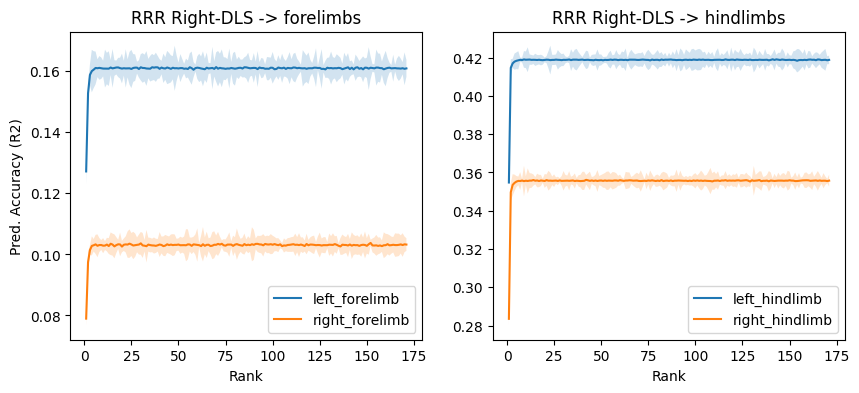

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex='all')
vizutils.shaded_errorbar(ax[0], rank_list, cv_scores_left_forelimb, label='left_forelimb')
vizutils.shaded_errorbar(ax[0], rank_list, cv_scores_right_forelimb, label='right_forelimb')

vizutils.shaded_errorbar(ax[1], rank_list, cv_scores_left_hindlimb, label='left_hindlimb')
vizutils.shaded_errorbar(ax[1], rank_list, cv_scores_right_hindlimb, label='right_hindlimb')

ax[0].set_title('RRR Right-DLS -> forelimbs')
ax[0].legend()
ax[1].set_title('RRR Right-DLS -> hindlimbs')
ax[1].legend()
ax[0].set_ylabel('Pred. Accuracy (R2)')
ax[0].set_xlabel('Rank')
ax[1].set_xlabel('Rank')
# ax[1].set_xlim(0, 20)


plt.show()

In [ ]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')

Dropped 11 of 333 rows (3.30%).


In [ ]:
def get_cv_scoress_all_components(
    X, y, cv=KFold(5, shuffle=True), reg=None, step=5
):

    max_possible_comp = X.shape[1]
    print(f"Max possible components: {max_possible_comp}")
    comp_list = np.arange(1, max_possible_comp, step=step)

    cv_scores = []
    for comp in tqdm(comp_list):
        cv_scores.append(
            cross_val_score(
                decode.ReducedRankRegressorBence(max_possible_comp, reg=reg),
                X[:, :comp],
                y,
                cv=cv,
                scoring=decode.get_custom_scorer(),
            )
        )
    cv_scores = np.stack(cv_scores)
    return comp_list, cv_scores

cv_comps = {}
for body_part in ["left_forelimb", "left_hindlimb", "right_forelimb", "right_hindlimb"]:
    df__ = dt.add_bhv(df, bhv_fields=bhv_combinations[body_part])
    perturb_td = pyal.restrict_to_interval(df__, 'idx_sol_on', rel_start = -100, rel_end= 150)

    X = np.concatenate(perturb_td.CP_rates_pca.values)
    y = np.concatenate(perturb_td.bhv.values)

    comp_list, cv_comps[body_part]= get_cv_scoress_all_components(X, y, step=1)

Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.37it/s]


Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.37it/s]


Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.37it/s]


Max possible components: 172


100%|██████████| 171/171 [00:50<00:00,  3.36it/s]


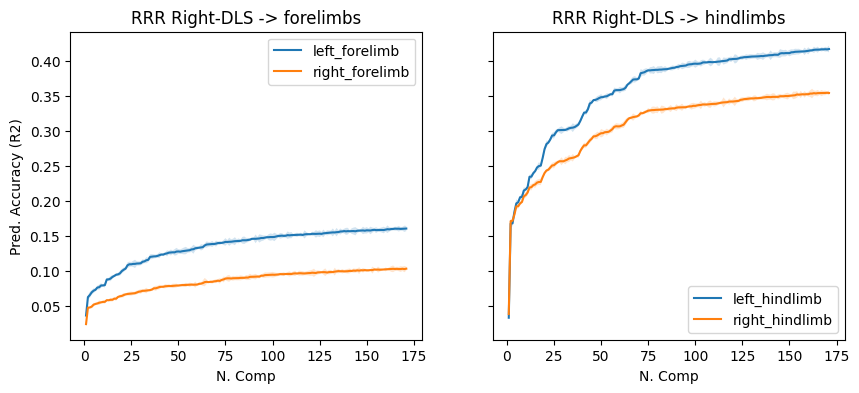

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex='all', sharey='all')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps["left_forelimb"], label='left_forelimb')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps["right_forelimb"], label='right_forelimb')

vizutils.shaded_errorbar(ax[1], comp_list, cv_comps["left_hindlimb"], label='left_hindlimb')
vizutils.shaded_errorbar(ax[1], comp_list, cv_comps["right_hindlimb"], label='right_hindlimb')

ax[0].set_title('RRR Right-DLS -> forelimbs')
ax[0].legend()
ax[1].set_title('RRR Right-DLS -> hindlimbs')
ax[1].legend()
ax[0].set_ylabel('Pred. Accuracy (R2)')
ax[0].set_xlabel('N. Comp')
ax[1].set_xlabel('N. Comp')
# ax[1].set_xlim(0, 20)


plt.show()

In [ ]:
cv_comps_mop = {}
for body_part in ["left_forelimb", "left_hindlimb", "right_forelimb", "right_hindlimb"]:
    df__ = dt.add_bhv(df, bhv_fields=bhv_combinations[body_part])
    perturb_td = pyal.restrict_to_interval(df__, 'idx_sol_on', rel_start = -100, rel_end= 150)

    X = np.concatenate(perturb_td.MOp_rates_pca.values)
    y = np.concatenate(perturb_td.bhv.values)

    comp_list, cv_comps_mop[body_part]= get_cv_scoress_all_components(X, y, step=1)

Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.20it/s]


Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.18it/s]


Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.22it/s]


Max possible components: 178


100%|██████████| 177/177 [00:55<00:00,  3.18it/s]


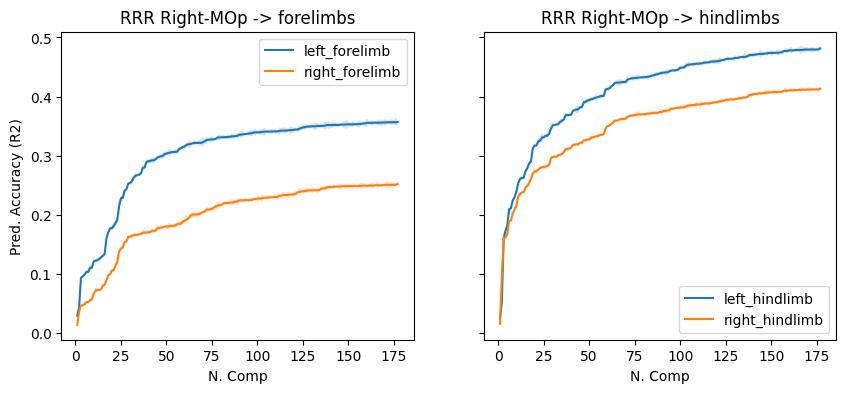

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4), sharex='all', sharey='all')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps_mop["left_forelimb"], label='left_forelimb')
vizutils.shaded_errorbar(ax[0], comp_list, cv_comps_mop["right_forelimb"], label='right_forelimb')

vizutils.shaded_errorbar(ax[1], comp_list, cv_comps_mop["left_hindlimb"], label='left_hindlimb')
vizutils.shaded_errorbar(ax[1], comp_list, cv_comps_mop["right_hindlimb"], label='right_hindlimb')

ax[0].set_title('RRR Right-MOp -> forelimbs')
ax[0].legend()
ax[1].set_title('RRR Right-MOp -> hindlimbs')
ax[1].legend()
ax[0].set_ylabel('Pred. Accuracy (R2)')
ax[0].set_xlabel('N. Comp')
ax[1].set_xlabel('N. Comp')
# ax[1].set_xlim(0, 20)


plt.show()

In [ ]:
comp_list_mop, comp_list_cp = np.arange(1, 178), np.arange(1, 172)


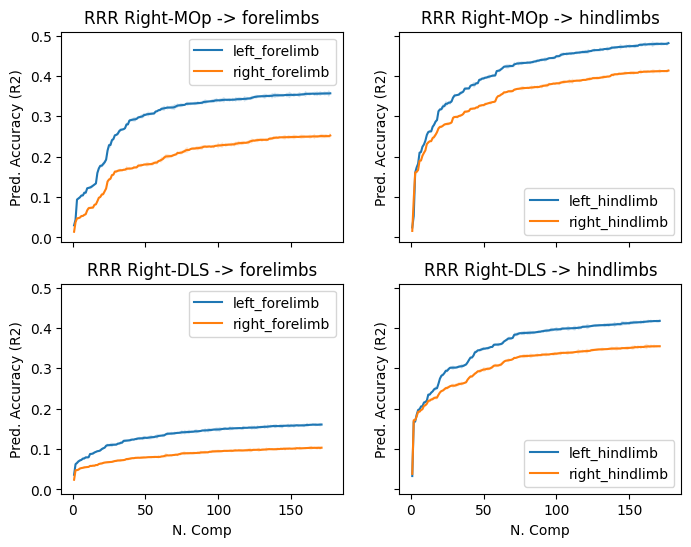

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex='all', sharey='all')
axs = axs.flatten()
for ax, fore in zip(axs[:2], ['fore', 'hind']):
    vizutils.shaded_errorbar(ax, comp_list_mop, cv_comps_mop[f"left_{fore}limb"], label=f"left_{fore}limb")
    vizutils.shaded_errorbar(ax, comp_list_mop, cv_comps_mop[f"right_{fore}limb"], label=f"right_{fore}limb")
    ax.set_title(f'RRR Right-MOp -> {fore}limbs')
    ax.set_ylabel('Pred. Accuracy (R2)')
    ax.legend()

for ax, fore in zip(axs[2:], ['fore', 'hind']):
    vizutils.shaded_errorbar(ax, comp_list, cv_comps[f"left_{fore}limb"], label=f"left_{fore}limb")
    vizutils.shaded_errorbar(ax, comp_list, cv_comps[f"right_{fore}limb"], label=f"right_{fore}limb")
    ax.set_title(f'RRR Right-DLS -> {fore}limbs')

    ax.set_ylabel('Pred. Accuracy (R2)')
    ax.legend()
    ax.set_xlabel('N. Comp')



# ax[0].legend()
# ax[1].set_title('RRR Right-MOp -> hindlimbs')
# ax[1].legend()
# ax[0].set_xlabel('N. Comp')
# ax[1].set_xlabel('N. Comp')
# ax[1].set_xlim(0, 20)


plt.show()

## How does MOp predict DLS?

In [ ]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)

Dropped 11 of 333 rows (3.30%).


In [ ]:
X = np.concatenate(perturb_td.MOp_rates_pca.values)
y = np.concatenate(perturb_td.CP_rates_pca.values)

rank_list, cv_scores_mop_dls = get_cv_scoress_all_ranks(X, y, step=5, cv=KFold(5, shuffle=False))

Max possible rank: 178


100%|██████████| 36/36 [00:33<00:00,  1.08it/s]


In [ ]:
perturb_td.head()

,animal,session,trial_id,trial_name,trial_length,bin_size,idx_trial_start,idx_trial_end,idx_CPI,values_before_camera_trigger,...,GPe_rates,CP_rates,MOp_rates,sol_level_id,sol_contra_ipsi,SSp_rates_pca,VAL_rates_pca,GPe_rates_pca,CP_rates_pca,MOp_rates_pca
0,M061,M061_2025_03_06_14_00,362,trial,600,0.01,NaN,NaN,[],[],...,"[[33.043865, 8.714462, 39.19829, 8.835436, 0.0...","[[2.5908494, 52.45501, 24.812037, 19.728403, 5...","[[0.41590264, 7.428162, 0.0, 16.263794, 10.426...",0.0,1.0,"[[35.341667, -5.2573395, -22.729324, 10.11895,...","[[-25.079666, 32.7854, -12.578241, 2.1424255, ...","[[27.911499, 34.50815, 30.36084, -39.58062, 11...","[[-17.916824, 0.3288226, -8.99432, -4.0952682,...","[[-26.079391, -0.26727295, -9.544258, 7.934238..."
1,M061,M061_2025_03_06_14_00,278,trial,600,0.01,NaN,NaN,[],[],...,"[[36.272224, 22.210196, 40.69343, 15.754596, 0...","[[4.357046, 36.13122, 17.543253, 16.256767, 2....","[[0.0, 7.3918767, 0.0, 23.848278, 3.4276934, 0...",1.0,0.0,"[[43.931664, 12.338989, -25.177628, -9.611326,...","[[-11.35841, -0.917408, -35.79841, 12.795357, ...","[[26.160892, 8.89624, -24.63818, 26.79525, -31...","[[-27.475224, 1.1151538, -10.176842, -10.28398...","[[-18.373535, 8.893162, 1.9244375, 9.601856, -..."
2,M061,M061_2025_03_06_14_00,410,trial,600,0.01,NaN,NaN,[],[],...,"[[51.639717, 18.861393, 30.44932, 0.019238899,...","[[5.904538, 47.763004, 12.62192, 28.212696, 0....","[[0.0, 25.254036, 0.0, 39.12522, 1.8835385, 0....",0.0,1.0,"[[32.3291, 7.432617, -17.54789, -12.067068, 10...","[[-6.016775, 48.48452, 15.100374, 14.558128, 1...","[[21.50478, -3.2693024, 25.015038, 41.798016, ...","[[2.7939415, 4.988885, 48.37245, 43.796013, -0...","[[-10.833656, 32.957157, -5.841382, 23.022678,..."
3,M061,M061_2025_03_06_14_00,20,trial,600,0.01,NaN,NaN,[],[],...,"[[30.54065, 15.351261, 49.18524, 0.0, 0.0, 49....","[[18.378092, 52.27891, 14.117314, 19.913557, 0...","[[7.3958497, 0.0, 35.974606, 0.11905071, 0.208...",1.0,0.0,"[[-65.05404, 18.87262, 2.4947128, 16.639816, 1...","[[-22.30351, -28.51296, -24.130198, -23.992783...","[[-106.00157, 30.83194, 4.2491493, -8.469657, ...","[[-6.3049927, -32.107285, -8.015403, -10.91226...","[[-37.07766, -34.982624, 23.358334, -0.4217415..."
4,M061,M061_2025_03_06_14_00,222,trial,600,0.01,NaN,NaN,[],[],...,"[[27.25778, 24.49497, 45.42412, 12.428355, 0.0...","[[4.471336, 57.272114, 15.255565, 29.290209, 0...","[[0.0, 13.040992, 0.0, 34.937145, 7.0398474, 0...",1.0,0.0,"[[7.45912, 8.103798, 6.036972, -13.952095, 18....","[[3.7389374, -7.7232933, -2.7215023, 7.6336365...","[[-11.521816, 14.936539, -16.658848, 10.350724...","[[-4.849167, -1.1704302, -2.4043493, 9.988712,...","[[-4.7845535, 21.923252, 19.094872, -19.006933..."


(0.0, 40.0)

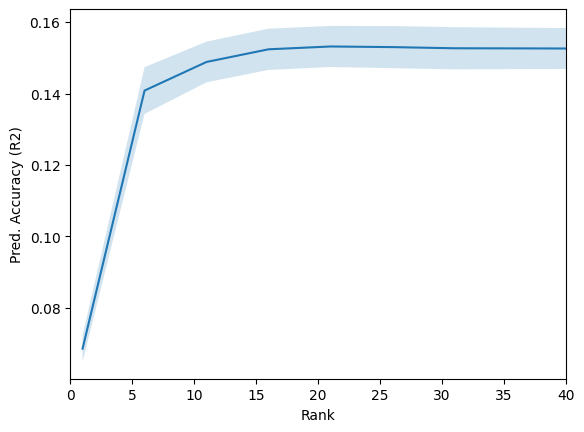

In [ ]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, rank_list, cv_scores_mop_dls)
# vizutils.shaded_errorbar(ax, cv_scores_val_dls)

# ax.axhline(0.182)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Rank')
ax.set_xlim(0, 40)

(0.19, 0.22)

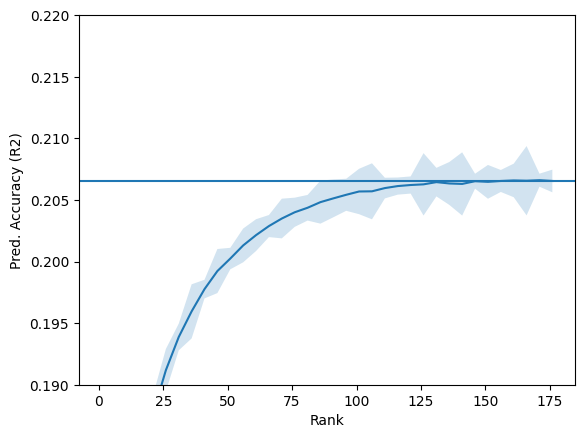

In [ ]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, rank_list, cv_scores_mop_dls)
# vizutils.shaded_errorbar(ax, cv_scores_val_dls)

ax.axhline(0.2065)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Rank')
ax.set_ylim(0.19, 0.22)

(0.0, 40.0)

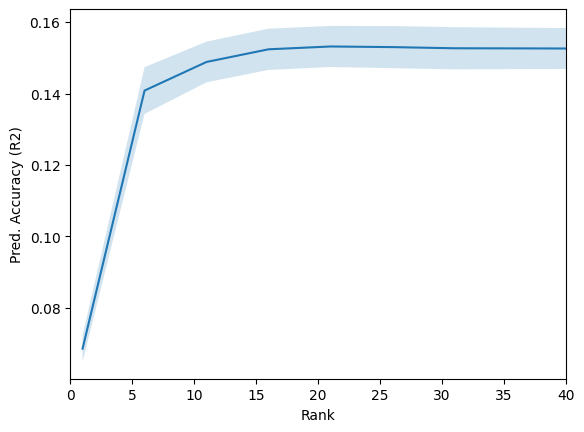

In [ ]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, rank_list, cv_scores_mop_dls)
# vizutils.shaded_errorbar(ax, cv_scores_val_dls)

# ax.axhline(0.182)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Rank')
ax.set_xlim(0, 40)

## How does VAL predict kinematics?

In [85]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df)
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)

Dropped 11 of 333 rows (3.30%).


In [ ]:
def get_cv_scoress_all_components_gpu(
    X, y, cv=KFold(5, shuffle=False), reg=None, step=5
):

    max_possible_comp = X.shape[1]
    print(f"Max possible components: {max_possible_comp}")
    comp_list = np.arange(1, max_possible_comp, step=step)

    cv_scores = []
    for comp in tqdm(comp_list):
        cv_scores.append(
            cross_val_score(
                decode.ReducedRankRegressorBenceGPU(max_possible_comp),
                X[:, :comp],
                y,
                cv=cv,
                scoring=decode.get_custom_scorer(),
            )
        )
    cv_scores = np.stack(cv_scores)
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()

    # Clear the memory pool.
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()

    return comp_list, cv_scores

def get_cv_scoress_all_ranks_gpu(
    X, y, cv=KFold(5, shuffle=False), reg=None, step=5
):

    max_possible_rank = X.shape[1]
    print(f"Max possible ranks: {max_possible_rank}")
    rank_list = np.arange(1, max_possible_rank, step=step)

    cv_scores = []
    for rank in tqdm(rank_list):
        cv_scores.append(
            cross_val_score(
                decode.ReducedRankRegressorBenceGPU(rank),
                X,
                y,
                cv=cv,
                scoring=decode.get_custom_scorer(),
            )
        )
    cv_scores = np.stack(cv_scores)
    mempool = cp.get_default_memory_pool()
    pinned_mempool = cp.get_default_pinned_memory_pool()

    # Clear the memory pool.
    mempool.free_all_blocks()
    pinned_mempool.free_all_blocks()

    return rank_list, cv_scores



In [ ]:
cv_comps_into_cp = {}
for area in ['MOp', 'VAL']:
    X = np.concatenate(perturb_td[f"{area}_rates_pca"].values)
    y = np.concatenate(perturb_td[f"CP_rates_pca"].values)

    comp_list, cv_comps_into_cp[area]= get_cv_scoress_all_components_gpu(X, y, step=1)

Max possible components: 178


100%|██████████| 177/177 [00:50<00:00,  3.53it/s]


Max possible components: 168


100%|██████████| 167/167 [00:44<00:00,  3.75it/s]


In [ ]:
cv_ranks_into_cp = {}
for area in ['MOp', 'VAL']:
    X = np.concatenate(perturb_td[f"{area}_rates_pca"].values)
    y = np.concatenate(perturb_td[f"CP_rates_pca"].values)

    rank_list, cv_ranks_into_cp[area]= get_cv_scoress_all_ranks_gpu(X, y, step=1)

Max possible ranks: 178


100%|██████████| 177/177 [00:55<00:00,  3.17it/s]


Max possible ranks: 168


100%|██████████| 167/167 [00:52<00:00,  3.20it/s]


Text(0.5, 0, 'Components')

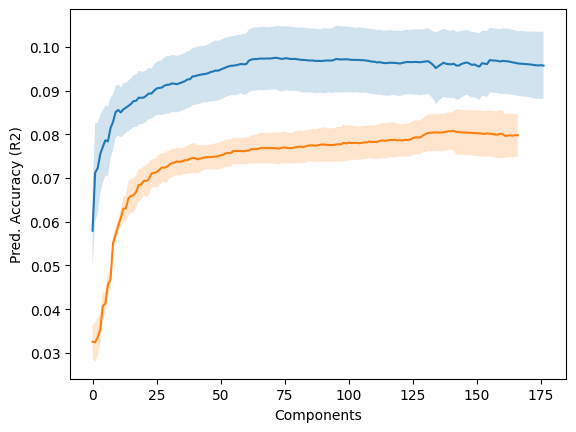

In [ ]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, cv_comps_into_cp['MOp'])
vizutils.shaded_errorbar(ax, cv_comps_into_cp['VAL'])

# ax.set_xlim(0, 120)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Components')


Text(0.5, 0, 'Components')

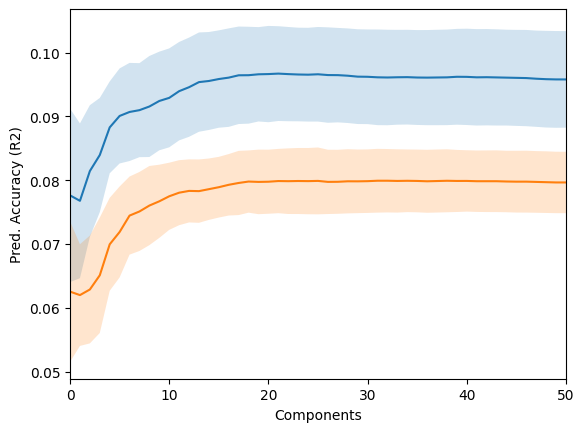

In [ ]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, cv_ranks_into_cp['MOp'])
vizutils.shaded_errorbar(ax, cv_ranks_into_cp['VAL'])

ax.set_xlim(0, 50)
ax.set_ylabel('Pred. Accuracy (R2)')
ax.set_xlabel('Components')


### Take the subspace of VAL that best predicts forlimbs during a perturbation

In [86]:
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -10, rel_end= 100)
bhv = np.concatenate(perturb_td.bhv.values)
val = np.concatenate(perturb_td.VAL_rates_pca.values)
mop = np.concatenate(perturb_td.MOp_rates_pca.values)

In [79]:
cross_val_score(RidgeCV(), val, bhv, cv=5, scoring=decode.get_custom_scorer())

array([0.15466457, 0.22185492, 0.14821315, 0.13690694, 0.1487157 ])

In [9]:
def opt_ridge_alpha(x_cv, y_cv):
    alphas = np.logspace(-2, 6, 50)
    ridge_cv = RidgeCV(alphas=alphas)
    ridge_cv.fit(x_cv, y_cv)

    best_alpha = ridge_cv.alpha_
    return best_alpha

In [88]:
alpha = opt_ridge_alpha(val, bhv)
model_val = RidgeCV(alpha)
model_val.fit(val, bhv)

alpha = opt_ridge_alpha(mop, bhv)
model_mop = RidgeCV(alpha)
model_mop.fit(mop, bhv)

RidgeCV(alphas=15998.587196060573)

In [38]:
def get_output_potent_projector(regressor, var_X=None):
    """
    Matrix that projects input data into the regressor's output-potent subspace

    Parameters
    ----------
    regressor : sklearn.base.BaseEstimator
        fitted (linear) regressor
    var_X : np.array, optional
        if supplied, rotate the subspace axes according to
        explained variance in this array

    Returns
    -------
    projection matrix : np.ndarray
    """
    W = scipy.linalg.orth(regressor.coef_.T)
    return W
    
    
def get_output_null_projector(regressor, var_X=None):
    """
    Matrix that projects input data into the regressor's output-null subspace

    Parameters
    ----------
    regressor : sklearn.base.BaseEstimator
        fitted (linear) regressor
    var_X : np.array, optional
        if supplied, rotate the subspace axes according to
        explained variance in this array

    Returns
    -------
    projection matrix : np.ndarray
    """
    coef = regressor.coef_.copy()
    if coef.ndim == 1:
        coef = np.expand_dims(coef, 0)

    W = scipy.linalg.null_space(coef)
    return W


def project_signal(trial_data, W, signal, out_fieldname):
    """
    Project a signal using a weight matrix

    Parameters
    ----------
    trial_data : pd.DataFrame
        data in trial_data format
    W : np.array
        projection matrix
        shape: N x D
    signal : str
        signal to project
    out_fieldname : str
        name of the field in which to store the projections

    Returns
    -------
    trial_data with the projections added
    """
    trial_data = trial_data.copy()
    trial_data[out_fieldname] = [
        s @ W for s in trial_data[signal].values
    ]

    return trial_data

In [89]:
potent_dims_val = get_output_potent_projector(model_val) 
potent_dims_mop = get_output_potent_projector(model_mop) 


trial_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end= 200)

# %%
# project signal after centering
trial_td = project_signal(trial_td, potent_dims_val, 'VAL_rates_pca', "VAL_rates_pca_potent")
trial_td = project_signal(trial_td, potent_dims_mop, 'MOp_rates_pca', "MOp_rates_pca_potent")



In [29]:
np.stack(trial_td.VAL_rates_pca_potent.values).shape

(322, 401, 9)

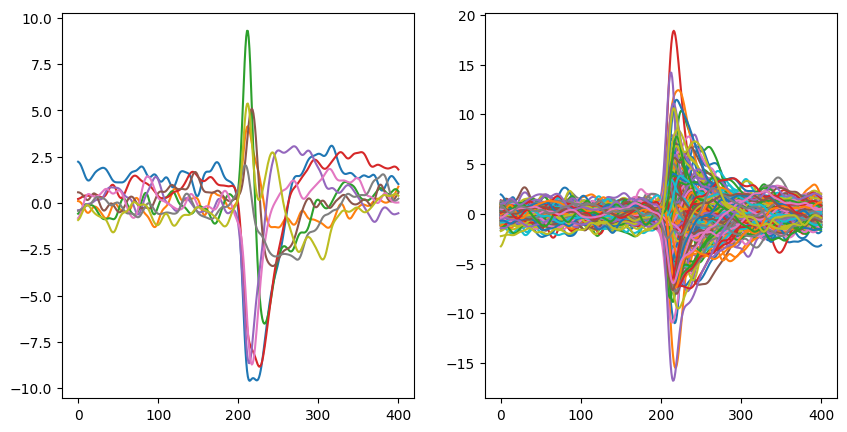

In [41]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
val_pot = np.stack(trial_td.VAL_rates_pca_potent.values)
val_null = np.stack(trial_td.VAL_rates_pca_null.values)

ax[0].plot(val_pot.mean(0))
ax[1].plot(val_null.mean(0))

plt.show()

In [93]:
post_perturb_td = pyal.restrict_to_interval(trial_td, 'idx_sol_on', rel_start = -10, rel_end= 100)
post_perturb_td = post_perturb_td.sample(frac=1, random_state=42).reset_index(drop=True)


X = np.concatenate(post_perturb_td.MOp_rates_pca_potent.values)
y = np.concatenate(post_perturb_td.CP_rates_pca.values)
alpha = opt_ridge_alpha(X, y)

scores = cross_val_score(
    Ridge(alpha=alpha), 
    X, 
    y, 
    cv=KFold(5, shuffle=False),
    scoring=decode.get_custom_scorer()
)
print(f"Avg. score across folds: {scores.mean():.4f}")

Avg. score across folds: 0.1501


In [95]:
post_perturb_td = pyal.restrict_to_interval(trial_td, 'idx_sol_on', rel_start = -10, rel_end= 100)
post_perturb_td = post_perturb_td.sample(frac=1, random_state=42).reset_index(drop=True)


X = np.concatenate(post_perturb_td.VAL_rates_pca.values)
y = np.concatenate(post_perturb_td.SSp_rates_pca.values)
alpha = opt_ridge_alpha(X, y)

scores = cross_val_score(
    Ridge(alpha=alpha), 
    X, 
    y, 
    cv=KFold(5, shuffle=False),
    scoring=decode.get_custom_scorer()
)
print(f"Avg. score across folds: {scores.mean():.4f}")

Avg. score across folds: 0.1849


## VAL per components

In [111]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df, bhv_fields=['right_paw'])
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end= 150)

Dropped 11 of 333 rows (3.30%).


In [115]:
area = "VAL"
# alpha = opt_ridge_alpha(
#     np.concatenate(perturb_td[f"{area}_rates_pca"].values), 
#     np.concatenate(perturb_td.bhv.values)
# )
# alpha = 0.05
# scores = {}
# scores['right_paw'] = {}
scores['left_paw']['VAL'], times = decode.regression_moving_window(
                np.stack(perturb_td[f"{area}_rates_pca"].values),
                np.stack(perturb_td.bhv.values),
                window_length_bin=20,
                step_bin=2,
                cv=5,
                # min_time_bin=50,
                # max_time_bin=375,
                alpha=alpha
            )

  0%|          | 0/116 [00:00<?, ?it/s]

100%|██████████| 116/116 [00:19<00:00,  5.82it/s]


In [112]:
area = "VAL"
alpha = opt_ridge_alpha(
    np.concatenate(perturb_td[f"{area}_rates_pca"].values), 
    np.concatenate(perturb_td.bhv.values)
)
# alpha = 0.05
# scores = {}
# scores['right_paw'] = {}
scores['left_paw']['VAL'], times = decode.decoding_moving_window(
                decode.ReducedRankRegressorBenceGPU(rank=168, reg=alpha),
                np.stack(perturb_td[f"{area}_rates_pca"].values),
                np.stack(perturb_td.bhv.values),
                window_length_bin=20,
                step_bin=2,
                cv=5,
                # min_time_bin=100, 
                # max_time_bin=350
            )

100%|██████████| 116/116 [00:06<00:00, 17.01it/s]


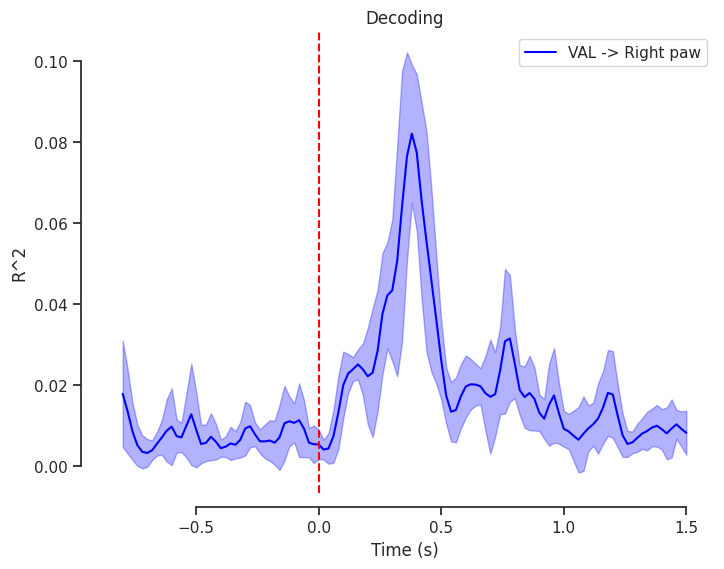

In [114]:
with vizutils.apply_plot_style('notebook'):
    fig, ax = plt.subplots(figsize=(8, 6))

    # vizutils.shaded_errorbar(ax, times-1, scores['left_paw']['VAL'],
    #                             color='blue', alpha_err=0.3, label='VAL -> Left paw')
    vizutils.shaded_errorbar(ax, times-1, scores['left_paw']['VAL'],
                                color='blue', alpha_err=0.3, label='VAL -> Right paw')
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel('R^2')
    ax.set_xlabel('Time (s)')
    # ax.set_xlim(-2, 2)
    ax.legend()
        
    ax.set_title('Decoding')
        
plt.show()

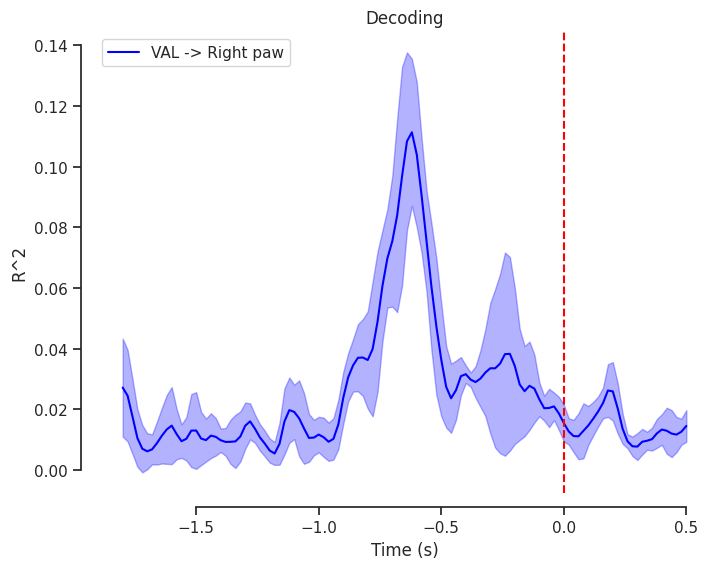

In [116]:
with vizutils.apply_plot_style('notebook'):
    fig, ax = plt.subplots(figsize=(8, 6))

    # vizutils.shaded_errorbar(ax, times-1, scores['left_paw']['VAL'],
    #                             color='blue', alpha_err=0.3, label='VAL -> Left paw')
    vizutils.shaded_errorbar(ax, times-2, scores['left_paw']['VAL'],
                                color='blue', alpha_err=0.3, label='VAL -> Right paw')
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel('R^2')
    ax.set_xlabel('Time (s)')
    # ax.set_xlim(-2, 2)
    ax.legend()
        
    ax.set_title('Decoding')
        
plt.show()

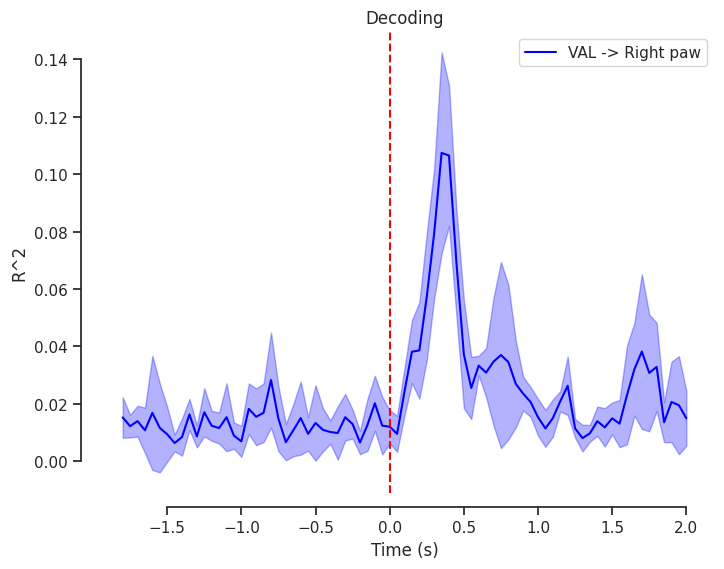

In [62]:
with vizutils.apply_plot_style('notebook'):
    fig, ax = plt.subplots(figsize=(8, 6))

    # vizutils.shaded_errorbar(ax, times-1, scores['left_paw']['VAL'],
    #                             color='blue', alpha_err=0.3, label='VAL -> Left paw')
    vizutils.shaded_errorbar(ax, times-2, scores['left_paw']['VAL'],
                                color='blue', alpha_err=0.3, label='VAL -> Right paw')
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel('R^2')
    ax.set_xlabel('Time (s)')
    # ax.set_xlim(-2, 2)
    ax.legend()
        
    ax.set_title('Decoding')
        
plt.show()

In [46]:
arr = np.stack(perturb_td[f"{area}_rates_pca"].values)
arr_shift = dim._roll_array(arr, shift=1, axis=1)

In [50]:
arr_shift[0, :, 1]

array([-2.44149017e+00, -2.06507473e+01, -2.23546696e+01, -2.39043140e+01,
       -2.52502193e+01, -2.63614044e+01, -2.72297268e+01, -2.78730659e+01,
       -2.83365860e+01, -2.86908073e+01, -2.90258293e+01, -2.94413204e+01,
       -3.00326500e+01, -3.08761787e+01, -3.20147285e+01, -3.34470940e+01,
       -3.51226845e+01, -3.69426765e+01, -3.87675247e+01, -4.04304619e+01,
       -4.17553139e+01, -4.25780678e+01, -4.27692947e+01, -4.22550926e+01,
       -4.10325928e+01, -3.91765556e+01, -3.68336830e+01, -3.42045212e+01,
       -3.15148277e+01, -2.89813347e+01, -2.67788620e+01, -2.50151196e+01,
       -2.37182789e+01, -2.28389435e+01, -2.22655697e+01, -2.18492069e+01,
       -2.14323368e+01, -2.08769608e+01, -2.00872288e+01, -1.90239944e+01,
       -1.77103786e+01, -1.62282257e+01, -1.47067528e+01, -1.33045082e+01,
       -1.21875496e+01, -1.15053978e+01, -1.13684464e+01, -1.18293419e+01,
       -1.28718891e+01, -1.44096432e+01, -1.62954540e+01, -1.83409691e+01,
       -2.03437157e+01, -

In [51]:
arr[0, :, 1]

array([-2.06507473e+01, -2.23546696e+01, -2.39043140e+01, -2.52502193e+01,
       -2.63614044e+01, -2.72297268e+01, -2.78730659e+01, -2.83365860e+01,
       -2.86908073e+01, -2.90258293e+01, -2.94413204e+01, -3.00326500e+01,
       -3.08761787e+01, -3.20147285e+01, -3.34470940e+01, -3.51226845e+01,
       -3.69426765e+01, -3.87675247e+01, -4.04304619e+01, -4.17553139e+01,
       -4.25780678e+01, -4.27692947e+01, -4.22550926e+01, -4.10325928e+01,
       -3.91765556e+01, -3.68336830e+01, -3.42045212e+01, -3.15148277e+01,
       -2.89813347e+01, -2.67788620e+01, -2.50151196e+01, -2.37182789e+01,
       -2.28389435e+01, -2.22655697e+01, -2.18492069e+01, -2.14323368e+01,
       -2.08769608e+01, -2.00872288e+01, -1.90239944e+01, -1.77103786e+01,
       -1.62282257e+01, -1.47067528e+01, -1.33045082e+01, -1.21875496e+01,
       -1.15053978e+01, -1.13684464e+01, -1.18293419e+01, -1.28718891e+01,
       -1.44096432e+01, -1.62954540e+01, -1.83409691e+01, -2.03437157e+01,
       -2.21164436e+01, -

In [117]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df, bhv_fields=['right_paw'])
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)


Dropped 11 of 333 rows (3.30%).


In [118]:
area = "VAL"
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end= 200)

alpha = opt_ridge_alpha(
    np.concatenate(perturb_td[f"{area}_rates_pca"].values), 
    np.concatenate(perturb_td.bhv.values)
)

In [148]:
mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()

# You can clear the memory pool by calling `free_all_blocks`.
mempool.free_all_blocks()
pinned_mempool.free_all_blocks()

In [151]:
y_.reshape(-1, 3).shape

(129122, 3)

In [152]:

import cupy as cp

scores_shifts_val_right_paw = {}

shifts_ms = np.arange(-100, 110, step=10)
shifts_bins = np.arange(-10, 11, step=1)

for idx, shift_bin in enumerate(shifts_bins):
        y = np.stack(perturb_td.bhv.values)
        y_ = dim._roll_array(y, shift=shift_bin, axis=1)

        alpha = opt_ridge_alpha(
                np.concatenate(perturb_td[f"{area}_rates_pca"].values), 
                y_.reshape(-1, 3)
                )
        
        print(f"Shift: {shifts_ms[idx]}")

        scores_shifts_val_right_paw[shifts_ms[idx]], times = decode.decoding_moving_window(
                decode.ReducedRankRegressorBenceGPU(rank=168, reg=alpha),
                np.stack(perturb_td[f"{area}_rates_pca"].values),
                y_,
                window_length_bin=20,
                step_bin=1,
                cv=5,
                min_time_bin=100, 
                max_time_bin=350
            )

mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()

# You can clear the memory pool by calling `free_all_blocks`.
mempool.free_all_blocks()
pinned_mempool.free_all_blocks()


Shift: -100


100%|██████████| 231/231 [00:13<00:00, 17.11it/s]


Shift: -90


100%|██████████| 231/231 [00:13<00:00, 17.21it/s]


Shift: -80


...

100%|██████████| 231/231 [00:13<00:00, 17.22it/s]


Shift: 90


100%|██████████| 231/231 [00:13<00:00, 17.28it/s]


Shift: 100


100%|██████████| 231/231 [00:13<00:00, 17.28it/s]


[ 0 10 20 30]


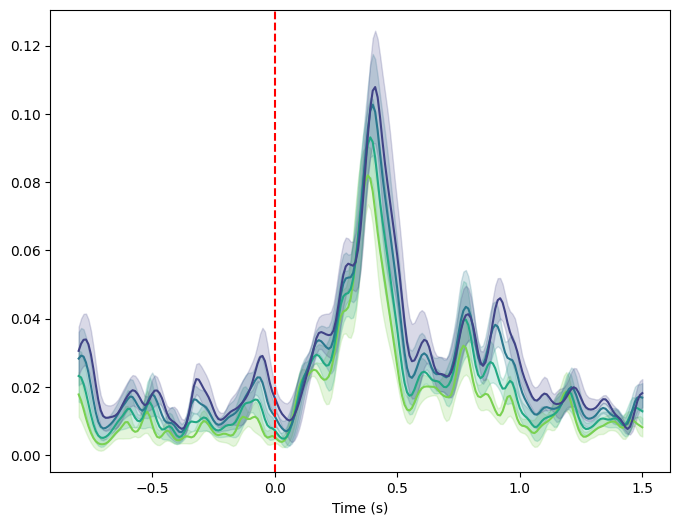

In [153]:
cmap = plt.get_cmap('viridis_r')
colors = cmap(np.linspace(0.2, .8, len(scores_shifts_val_right_paw)))

# with vizutils.apply_plot_style('notebook'):
fig, ax = plt.subplots(figsize=(8, 6))

# for ax, shift in zip(axs, scores_shifts_val_right_paw.keys()):
# for (shift, color) in zip(scores_shifts_val_right_paw.keys(),colors):
shifts = shifts_ms[10:14]
colors = cmap(np.linspace(0.2, .8, len(shifts)))

for idx, shift in enumerate(shifts):
        vizutils.shaded_errorbar(
            ax,
            times - 2,
            scores_shifts_val_right_paw[shift],
            color=colors[idx],
            alpha_err=0.2,
            label=f'{shift}',
            errorStat=scipy.stats.sem
        )
ax.axvline(0, color='red', linestyle='dashed')
ax.set_xlabel('Time (s)')
print(shifts)
        
plt.show()

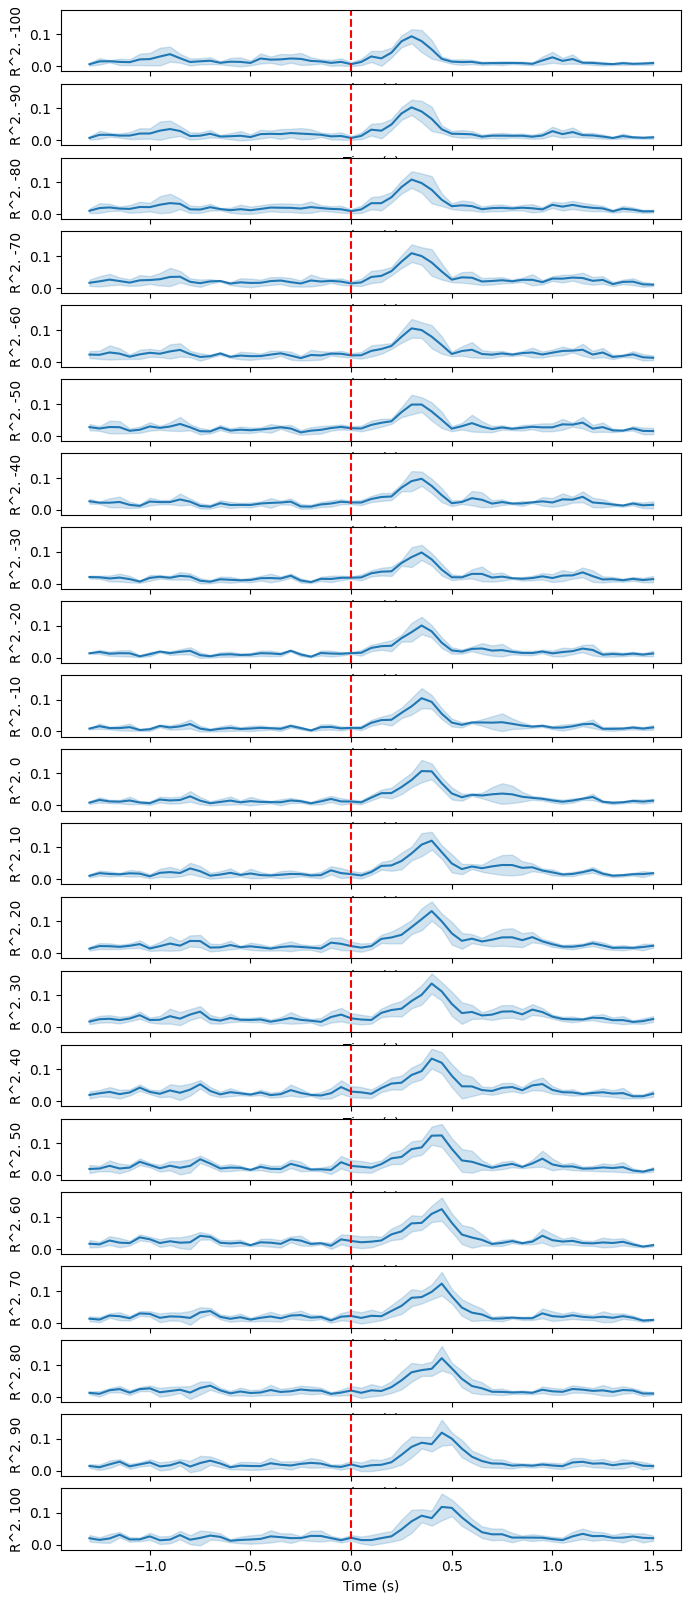

In [ ]:
# with vizutils.apply_plot_style('notebook'):
fig, axs = plt.subplots(21, 1, figsize=(8, 20), sharex='all', sharey='all')

for ax, shift in zip(axs, scores_shifts_val_right_paw.keys()):
    vizutils.shaded_errorbar(ax, times-2, scores_shifts_val_right_paw[shift],
                                color='tab:blue', alpha_err=0.2, label='VAL -> Right paw')
    ax.axvline(0, color='red', linestyle='dashed')
    ax.set_ylabel(f'R^2. {shift}')
    ax.set_xlabel('Time (s)')
    # ax.set_xlim(-2, 2)
    # ax.legend()
        
    # ax.set_title('Decoding')
        
plt.show()

# Lets try some principal angles

In [410]:
df.shape

(158, 87)

In [248]:
df = pyal.select_trials(df_, df_.trial_name == 'trial')
df = dt.add_pca_df(df, n_components=None)
df = dt.remove_trials_wo_motion_before_event(df, 'idx_motion', 'idx_sol_on')
df = dt.add_bhv(df)

df = df[~df["values_Sol_duration"].isin([50, 100])]
# df = df.sample(frac=1, random_state=42).reset_index(drop=True)


Dropped 11 of 333 rows (3.30%).


In [4]:
perturb_td_sens = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -110, rel_end= 20)
perturb_td_motor = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = 20, rel_end= 150)

sensory_pca = dim.compute_pca(np.concatenate(perturb_td_sens.VAL_rates.values), n_components=50)
sensory_emb = sensory_pca.components_.T
motor_pca = dim.compute_pca(np.concatenate(perturb_td_motor.VAL_rates.values), n_components=50)
motor_emb = motor_pca.components_.T


In [9]:
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)


overlaps = []

min_time_bin=100
max_time_bin=350
window_length_bin = 20
step_bin = 5
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)

X = np.stack(perturb_td.VAL_rates.values)
for t in tqdm(time_bins):
    # print(f"Interval {t} -> {t+window_length_bin}")
    X_ = X[:, t : t + window_length_bin, :]
    sensory_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
    sensory_emb = sensory_pca.components_.T

    overlaps_tmp = []
    for t in time_bins:
        X_ = X[:, t : t + window_length_bin, :]
        motor_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
        motor_emb = motor_pca.components_.T

        angles = scipy.linalg.subspace_angles(sensory_emb, motor_emb)
        overlap =  np.mean(np.cos(angles)**2)
        overlaps_tmp.append(overlap)

    overlaps_tmp = np.array(overlaps_tmp)
    overlaps.append(overlaps_tmp)

overlaps = np.array(overlaps)
time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * 0.01
time_points = time_points - 2

100%|██████████| 47/47 [01:39<00:00,  2.11s/it]


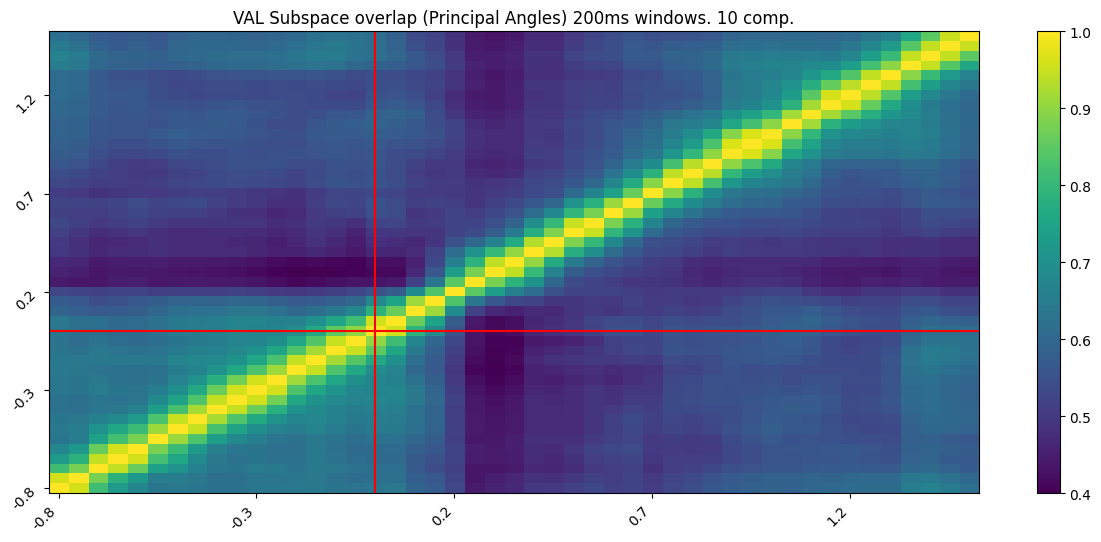

In [23]:
fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(overlaps, origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
im.set_clim(0.4, 1)

xticks_pos = np.arange(0, overlaps.shape[1], 10)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
ax.axhline(np.where(time_points == 0), color='r')
ax.set_title('VAL Subspace overlap (Principal Angles) 200ms windows. 10 comp.')

plt.show()

In [17]:
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)


overlaps_mop = []

min_time_bin=100
max_time_bin=350
window_length_bin = 20
step_bin = 5
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)

X = np.stack(perturb_td.MOp_rates.values)
for t in tqdm(time_bins):
    # print(f"Interval {t} -> {t+window_length_bin}")
    X_ = X[:, t : t + window_length_bin, :]
    sensory_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
    sensory_emb = sensory_pca.components_.T

    overlaps_tmp = []
    for t in time_bins:
        X_ = X[:, t : t + window_length_bin, :]
        motor_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
        motor_emb = motor_pca.components_.T

        angles = scipy.linalg.subspace_angles(sensory_emb, motor_emb)
        overlap =  np.mean(np.cos(angles)**2)
        overlaps_tmp.append(overlap)

    overlaps_tmp = np.array(overlaps_tmp)
    overlaps_mop.append(overlaps_tmp)

overlaps_mop = np.array(overlaps_mop)
time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * 0.01
time_points = time_points - 2

100%|██████████| 47/47 [01:17<00:00,  1.66s/it]


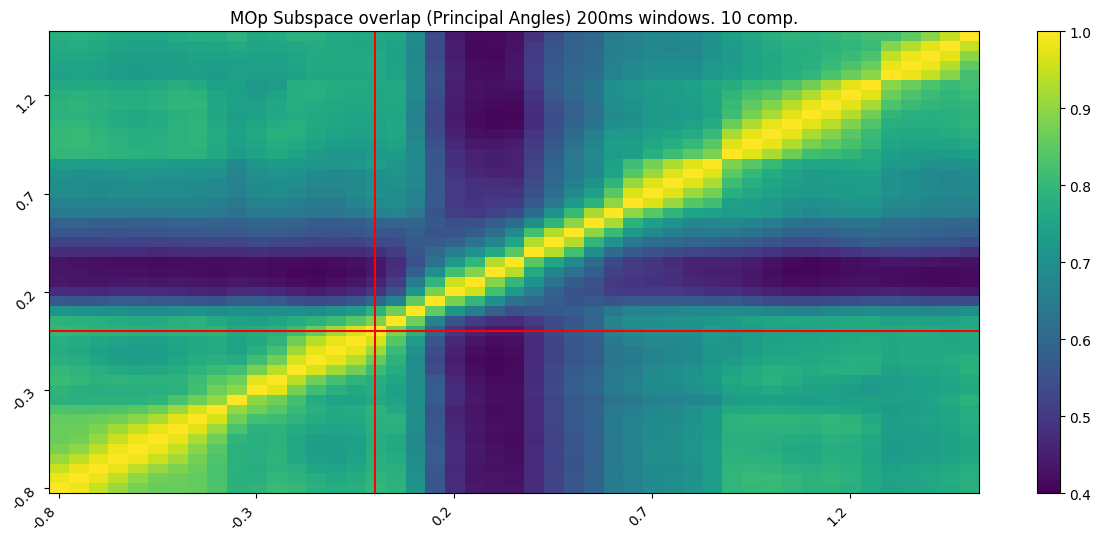

In [22]:
fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(overlaps_mop, origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
im.set_clim(0.4, 1)

xticks_pos = np.arange(0, overlaps_mop.shape[1], 10)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
ax.axhline(np.where(time_points == 0), color='r')
ax.set_title('MOp Subspace overlap (Principal Angles) 200ms windows. 10 comp.')

plt.show()

In [19]:
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)


overlaps_ssp = []

min_time_bin=100
max_time_bin=350
window_length_bin = 20
step_bin = 5
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)

X = np.stack(perturb_td.SSp_rates.values)
for t in tqdm(time_bins):
    # print(f"Interval {t} -> {t+window_length_bin}")
    X_ = X[:, t : t + window_length_bin, :]
    sensory_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
    sensory_emb = sensory_pca.components_.T

    overlaps_tmp = []
    for t in time_bins:
        X_ = X[:, t : t + window_length_bin, :]
        motor_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
        motor_emb = motor_pca.components_.T

        angles = scipy.linalg.subspace_angles(sensory_emb, motor_emb)
        overlap =  np.mean(np.cos(angles)**2)
        overlaps_tmp.append(overlap)

    overlaps_tmp = np.array(overlaps_tmp)
    overlaps_ssp.append(overlaps_tmp)

overlaps_ssp = np.array(overlaps_ssp)
time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * 0.01
time_points = time_points - 2

100%|██████████| 47/47 [00:32<00:00,  1.43it/s]


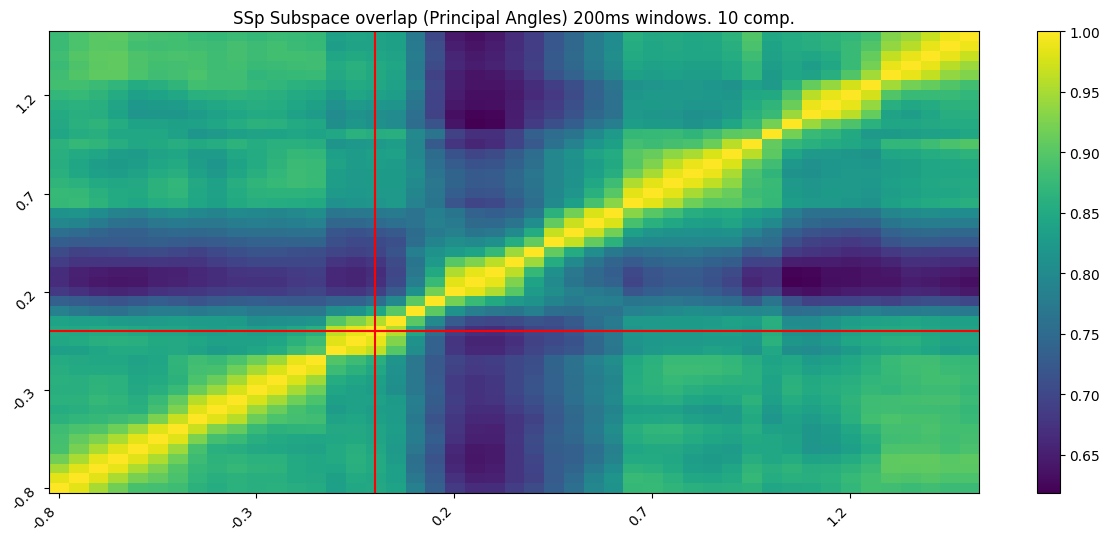

In [26]:
fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(overlaps_ssp, origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
# im.set_clim(0.4, 1)

xticks_pos = np.arange(0, overlaps_ssp.shape[1], 10)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
ax.axhline(np.where(time_points == 0), color='r')
ax.set_title('SSp Subspace overlap (Principal Angles) 200ms windows. 10 comp.')

plt.show()

In [28]:
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)


overlaps_cp = []

min_time_bin=100
max_time_bin=350
window_length_bin = 20
step_bin = 5
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)

X = np.stack(perturb_td.CP_rates.values)
for t in tqdm(time_bins):
    # print(f"Interval {t} -> {t+window_length_bin}")
    X_ = X[:, t : t + window_length_bin, :]
    sensory_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
    sensory_emb = sensory_pca.components_.T

    overlaps_tmp = []
    for t in time_bins:
        X_ = X[:, t : t + window_length_bin, :]
        motor_pca = dim.compute_pca(X_.reshape(-1, X.shape[-1]), n_components=10)
        motor_emb = motor_pca.components_.T

        angles = scipy.linalg.subspace_angles(sensory_emb, motor_emb)
        overlap =  np.mean(np.cos(angles)**2)
        overlaps_tmp.append(overlap)

    overlaps_tmp = np.array(overlaps_tmp)
    overlaps_cp.append(overlaps_tmp)

overlaps_cp = np.array(overlaps_cp)
time_points = np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) * 0.01
time_points = time_points - 2

100%|██████████| 47/47 [01:24<00:00,  1.79s/it]


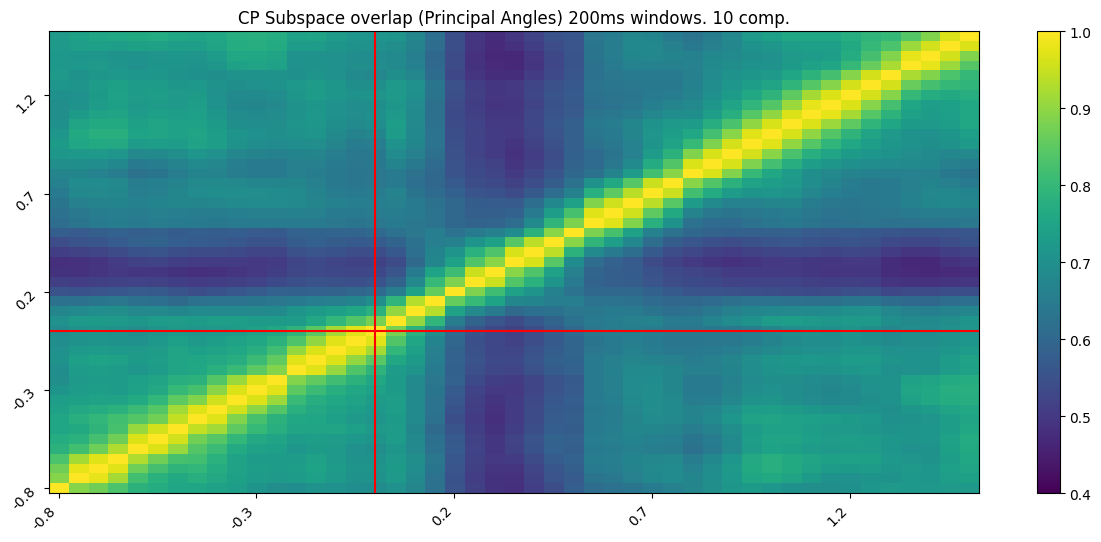

In [30]:
fig, ax = plt.subplots(figsize=(15, 6))
im = ax.imshow(overlaps_cp, origin='lower', cmap='viridis', aspect='auto')
cbar = fig.colorbar(im, ax=ax)
im.set_clim(0.4, 1)

xticks_pos = np.arange(0, overlaps_cp.shape[1], 10)       # positions
xticks_lab = np.round(time_points[xticks_pos], 3)      # labels (custom)

ax.set_xticks(xticks_pos)
ax.set_xticklabels(xticks_lab, rotation=45, ha='right')
ax.axvline(np.where(time_points == 0), color='r')

ax.set_yticks(xticks_pos)
ax.set_yticklabels(xticks_lab, rotation=45, ha='right')
ax.axhline(np.where(time_points == 0), color='r')
ax.set_title('CP Subspace overlap (Principal Angles) 200ms windows. 10 comp.')

plt.show()

# Sensory vs. motor subspaces

In [ ]:
perturb_td_sens = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = 0, rel_end=210)
perturb_td_motor = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = 50, rel_end=60)

# perturb_td_sens = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -100, rel_end=-90)
# perturb_td_motor = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -40, rel_end=-30)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)

areas = ["MOp", "SSp", 'CP', 'VAL']
comps = [20, 15, 20, 50]

embeddings = {}
for area, comp in zip(areas, comps):
    embeddings[area] = {}
    sensory_pca = dim.compute_pca(np.concatenate(perturb_td_sens[f"{area}_rates"].values), n_components=comp)
    embeddings[area]["sensory_emb"] = sensory_pca.components_.T

    motor_pca = dim.compute_pca(np.concatenate(perturb_td_motor[f"{area}_rates"].values), n_components=comp)
    embeddings[area]["motor_emb"] = motor_pca.components_.T


## Subspace alignment within each region

In [63]:
for area in areas:
    angles = scipy.linalg.subspace_angles(embeddings[area]["sensory_emb"], embeddings[area]["motor_emb"])
    overlap =  np.mean(np.cos(angles)**2)
    print(f"{area} Sensory/motor overlap: {overlap:.3f}")

MOp Sensory/motor overlap: 0.728
SSp Sensory/motor overlap: 0.816
CP Sensory/motor overlap: 0.696
VAL Sensory/motor overlap: 0.701


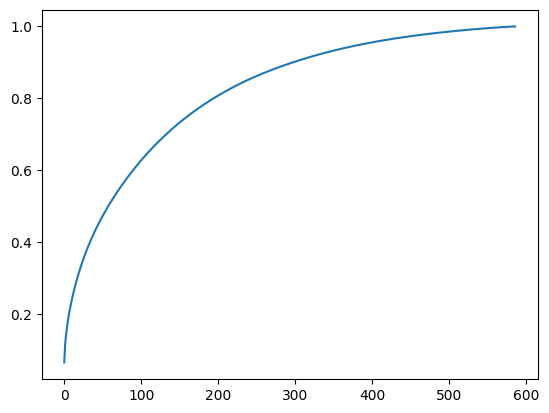

In [147]:
plt.plot(np.cumsum(global_pca.explained_variance_ratio_))

In [148]:
perturb_td_sens = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)

Z_all = np.hstack(
    [np.concatenate(perturb_td.MOp_rates.values),
    np.concatenate(perturb_td.SSp_rates.values),
    np.concatenate(perturb_td.CP_rates.values),
    np.concatenate(perturb_td.VAL_rates.values),]

)
k = 200
global_pca = dim.compute_pca(Z_all, n_components=k)
W_global = global_pca.components_.T 

region_latents = {}
region_embeddings = {}

n_neurons = 0

k_sens = 5
k_mot  = 5

for area in areas:
    region_embeddings[area] = {}

    area_activity = np.concatenate(perturb_td[f"{area}_rates"].values)
    n_trials, n_time, area_neurons = np.stack(perturb_td[f"{area}_rates"].values).shape


    region_latents[area] = area_activity @ W_global[n_neurons:n_neurons + area_neurons]

    region_latents[area] = region_latents[area].reshape(n_trials, n_time, k)
    region_latents_sens = region_latents[area][:, 200:250, :]
    region_latents_motor = region_latents[area][:, 0:150, :]

    sensory_pca = dim.compute_pca(region_latents_sens.reshape(-1, k), n_components=k_sens)
    region_embeddings[area]["sensory_emb"] = sensory_pca.components_.T

    motor_pca = dim.compute_pca(region_latents_motor.reshape(-1, k), n_components=k_mot)
    region_embeddings[area]["motor_emb"] = motor_pca.components_.T


    n_neurons = n_neurons + area_neurons

res = {}
for emb in region_embeddings[area].keys():
    res[emb] = {}
    for area in areas:
        res[emb][area] = {}

        for area_ in areas:
            angles = scipy.linalg.subspace_angles(region_embeddings[area][emb], region_embeddings[area_][emb])
            overlap =  np.mean(np.cos(angles)**2)
            res[emb][area][area_] = overlap

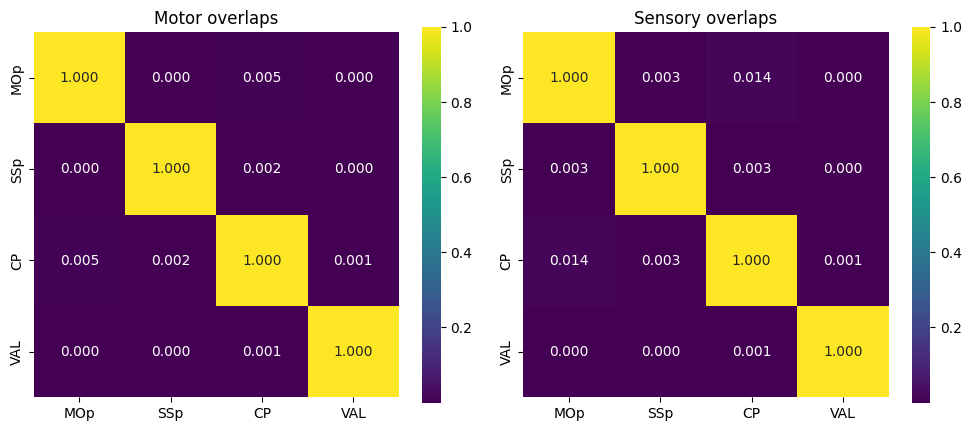

In [149]:
matrix_mot = np.zeros((len(areas), len(areas)))
matrix_sen = np.zeros((len(areas), len(areas)))

for i, a1 in enumerate(areas):
    for j, a2 in enumerate(areas):
        matrix_mot[i, j] = res['motor_emb'][a1][a2]
        matrix_sen[i, j] = res['sensory_emb'][a1][a2]


fig, ax = plt.subplots(1, 2, figsize=(10,5))
sns.heatmap(
    matrix_mot, 
    annot=True,       # write numbers in the boxes
    cmap="viridis",   
    xticklabels=areas,
    yticklabels=areas,
    square=True,
    ax=ax[0],
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)

sns.heatmap(
    matrix_sen, 
    annot=True,       # write numbers in the boxes
    cmap="viridis",   
    xticklabels=areas,
    yticklabels=areas,
    square=True,
    ax=ax[1],
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)

ax[0].set_title("Motor overlaps")
ax[1].set_title("Sensory overlaps")

plt.tight_layout()
plt.show()

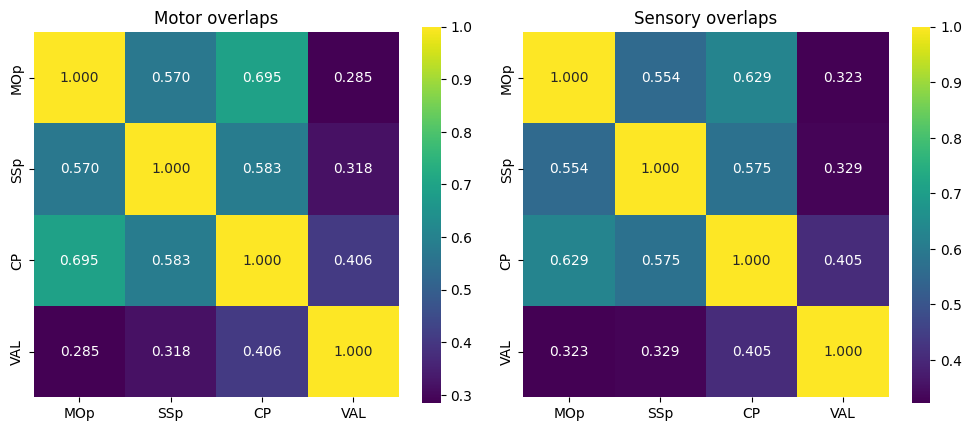

In [112]:
matrix_mot = np.zeros((len(areas), len(areas)))
matrix_sen = np.zeros((len(areas), len(areas)))

for i, a1 in enumerate(areas):
    for j, a2 in enumerate(areas):
        matrix_mot[i, j] = res['motor_emb'][a1][a2]
        matrix_sen[i, j] = res['sensory_emb'][a1][a2]


fig, ax = plt.subplots(1, 2, figsize=(10,5))
sns.heatmap(
    matrix_mot, 
    annot=True,       # write numbers in the boxes
    cmap="viridis",   
    xticklabels=areas,
    yticklabels=areas,
    square=True,
    ax=ax[0],
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)

sns.heatmap(
    matrix_sen, 
    annot=True,       # write numbers in the boxes
    cmap="viridis",   
    xticklabels=areas,
    yticklabels=areas,
    square=True,
    ax=ax[1],
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)

ax[0].set_title("Motor overlaps")
ax[1].set_title("Sensory overlaps")

plt.tight_layout()
plt.show()

In [156]:
cross_validated_pca_dim(Z_all, [2, 5, 10, 15, 20, 30, 40, 50, 75, 100, 200, 300])

k=2: mean MSE=58.444496, std=0.085603
k=5: mean MSE=54.532463, std=0.066112
k=10: mean MSE=50.533192, std=0.060249
k=15: mean MSE=47.520672, std=0.052524
k=20: mean MSE=45.051586, std=0.051385
k=30: mean MSE=40.983337, std=0.045408
k=40: mean MSE=37.706707, std=0.041921
k=50: mean MSE=34.937317, std=0.039680
k=75: mean MSE=29.263805, std=0.034012
k=100: mean MSE=24.701002, std=0.026254
k=200: mean MSE=12.785849, std=0.016366
k=300: mean MSE=6.523284, std=0.012299


([2, 5, 10, 15, 20, 30, 40, 50, 75, 100, 200, 300],
 array([58.444496, 54.532463, 50.53319 , 47.52067 , 45.051586, 40.983337,
        37.706707, 34.937317, 29.263805, 24.701002, 12.785849,  6.523284],
       dtype=float32),
 array([0.08560325, 0.06611249, 0.06024872, 0.05252439, 0.05138474,
        0.04540837, 0.04192064, 0.03968002, 0.03401184, 0.0262541 ,
        0.0163657 , 0.01229948], dtype=float32))

In [154]:
from sklearn.decomposition import PCA


def cross_validated_pca_dim(X_global, k_list=None, n_folds=5, random_state=0):
    """
    Compute cross-validated reconstruction error for PCA dimensionality selection.

    Parameters
    ----------
    X_global : ndarray, shape (T, N)
        Time x Neurons matrix (z-scored per neuron).
    k_list : list, candidate PCA dimensions to test.
    n_folds : int, number of CV folds.
    random_state : int, seed for KFold.

    Returns
    -------
    mean_errors : list
        Mean reconstruction error for each k in k_list.
    std_errors : list
        Std of error across folds.
    """

    if k_list is None:
        k_list = [2, 5, 10, 15, 20, 30, 40, 50, 75, 100]  # modify if needed

    T = X_global.shape[0]

    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)

    mean_errors = []
    std_errors = []

    for k in k_list:
        fold_errors = []

        for train_idx, test_idx in kf.split(np.arange(T)):

            X_train = X_global[train_idx]
            X_test  = X_global[test_idx]

            # Fit PCA on training set
            pca = PCA(n_components=k)
            pca.fit(X_train)

            # Reconstruct test set
            Z_test = pca.transform(X_test)                 # T_fold × k
            X_test_recon = pca.inverse_transform(Z_test)    # T_fold × N

            # Compute MSE reconstruction error
            mse = np.mean((X_test - X_test_recon) ** 2)
            fold_errors.append(mse)

        mean_errors.append(np.mean(fold_errors))
        std_errors.append(np.std(fold_errors))

        print(f"k={k}: mean MSE={mean_errors[-1]:.6f}, std={std_errors[-1]:.6f}")

    return k_list, np.array(mean_errors), np.array(std_errors)

## Time resolved activity

Take variance across trials, and then sum across the components axis. 

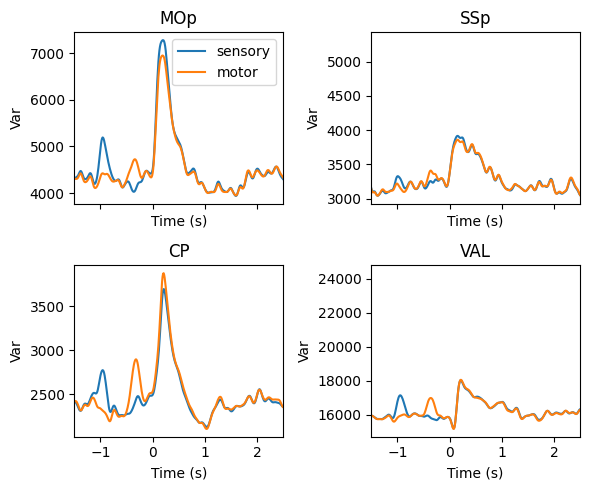

In [309]:
# with vizutils.apply_plot_style('talk'):
fig, axs = plt.subplots(2, 2, sharex='all', figsize=(6, 5))
axs = axs.flatten()
times = np.arange(-2, 3.01, step=0.01)

for area, ax in zip(areas, axs):
    ax.plot(
        times, 
        subspaces.variance_in_subspace_df(perturb_td, f'{area}_rates', embeddings[area]["sensory_emb"]), 
        label='sensory'
    )
    ax.plot(
        times, 
        subspaces.variance_in_subspace_df(perturb_td, f'{area}_rates', embeddings[area]["motor_emb"]), 
        label='motor'
    )
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Var')
    ax.set_title(area)
    # ax.set_yticklabels([])
ax.set_xlim(-1.5, 2.5)
axs[0].legend()

plt.tight_layout()

In [324]:
(np.concatenate(perturb_td_pre.MOp_rates_pca.values) @ embeddings["MOp"]["motor_emb"]).shape

(48300, 30)

In [325]:
np.concatenate(perturb_td_pre.left_elbow.values).shape

(48300, 3)

In [ ]:
perturb_td_pre = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -199, rel_end=-50)
# perturb_td_pre = perturb_td_pre.sample(frac=1, random_state=42).reset_index(drop=True)

full_model_score = cross_val_score(
    RidgeCV(),
    np.concatenate(perturb_td_pre.MOp_rates_pca.values)[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

proj = np.concatenate(perturb_td_pre.MOp_rates.values) @ embeddings["MOp"]["motor_emb"]
motor_subspace_score = cross_val_score(
    RidgeCV(),
    proj[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

proj = np.concatenate(perturb_td_pre.MOp_rates.values) @ embeddings["MOp"]["sensory_emb"]
sens_subspace_score = cross_val_score(
    RidgeCV(),
    proj[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

print(f"Full model score {full_model_score.mean(), full_model_score.std()}")
print(f"Motor subspace model score {motor_subspace_score.mean(), motor_subspace_score.std()}")
print(f"Sensory subspace model score {sens_subspace_score.mean(), sens_subspace_score.std()}")

Full model score (0.18451686494585015, 0.0320629231501846)
Motor subspace model score (0.19482682953421868, 0.048069224954979464)
Sensory subspace model score (0.18060723795485512, 0.03572986908165556)


In [100]:
df_inter = pyal.select_trials(df_, df_.trial_name == 'intertrial')
df_inter = dt.add_pca_df(df_inter, n_components=None)
df_inter = dt.add_bhv(df_inter)
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)
perturb_td_pre = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -199, rel_end=-10)
# perturb_td_pre = perturb_td_pre.sample(frac=1, random_state=42).reset_index(drop=True)


In [107]:

min_time_bin=100
max_time_bin=350
window_length_bin = 20
step_bin = 1
time_bins = np.arange(min_time_bin, max_time_bin + 1 - window_length_bin, step=step_bin)
time_points = (np.arange(min_time_bin + window_length_bin, max_time_bin + 1, step_bin) / 100) - 2

area = "CP"

k = 30

X_full_model_pca = np.concatenate(perturb_td_pre[f"{area}_rates_pca"].values)[:, :k]
X_rates = np.concatenate(perturb_td_pre[f"{area}_rates"].values)
n_neurons = X_rates.shape[-1]

X_rates_stacked = np.stack(perturb_td[f"{area}_rates"].values)
bhv = np.concatenate(perturb_td_pre.left_paw.values)

full_model_score = cross_val_score(
        RidgeCV(),
        X_full_model_pca,
        bhv,
        cv=3,
        scoring=decode.get_custom_scorer()
    )
print(f"Full model score: {full_model_score.mean()}")

embedding_scores = []
for t in tqdm(time_bins):
    X_rates_stacked_ = X_rates_stacked[:, t:t+window_length_bin, :]

    pca_model = dim.compute_pca(X_rates_stacked_.reshape(-1, n_neurons), n_components=k)
    embedding = pca_model.components_.T

    embedding_model_score = cross_val_score(
        decode.ReducedRankRegressorBenceGPU(rank=k),
        X_rates @ embedding,
        bhv,
        cv=KFold(3, shuffle=False),
        scoring=decode.get_custom_scorer()
    )
    embedding_scores.append(embedding_model_score)

    # print(f"Interval {np.round(time_points[idx], 3)} -> {np.round(time_points[idx] + window_length_bin/100, 3)}. Embedding model score {embedding_model_score.mean():.4f}")

embedding_scores = np.array(embedding_scores)

Full model score: 0.049027894237054954


100%|██████████| 231/231 [00:36<00:00,  6.25it/s]


In [108]:
mempool = cp.get_default_memory_pool()
pinned_mempool = cp.get_default_pinned_memory_pool()

# Clear the memory pool.
mempool.free_all_blocks()
pinned_mempool.free_all_blocks()

(<matplotlib.lines.Line2D at 0x7f34071e11f0>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7f34071aaf00>)

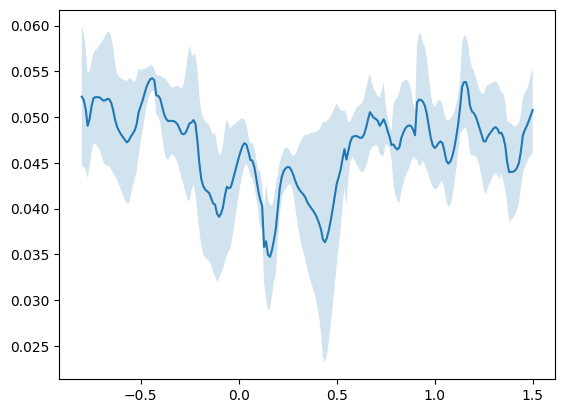

In [109]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, time_points, embedding_scores, errorStat=np.std)

(<matplotlib.lines.Line2D at 0x7f34070ad880>,
 <matplotlib.collections.FillBetweenPolyCollection at 0x7f34070ad160>)

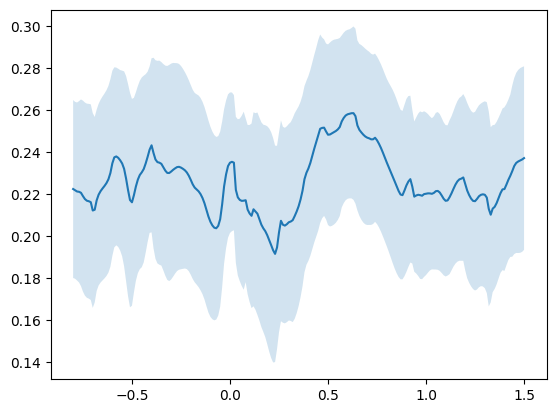

In [98]:
fig, ax = plt.subplots()
vizutils.shaded_errorbar(ax, time_points, embedding_scores)

In [436]:
perturb_td_pre = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -199, rel_end=-50)
# perturb_td_pre = perturb_td_pre.sample(frac=1, random_state=42).reset_index(drop=True)

full_model_score = cross_val_score(
    RidgeCV(),
    np.concatenate(perturb_td_pre.MOp_rates_pca.values)[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

proj = np.concatenate(perturb_td_pre.MOp_rates.values) @ embeddings["MOp"]["motor_emb"]
motor_subspace_score = cross_val_score(
    RidgeCV(),
    proj[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

proj = np.concatenate(perturb_td_pre.MOp_rates.values) @ embeddings["MOp"]["sensory_emb"]
sens_subspace_score = cross_val_score(
    RidgeCV(),
    proj[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

print(f"Full model score {full_model_score.mean(), full_model_score.std()}")
print(f"Motor subspace model score {motor_subspace_score.mean(), motor_subspace_score.std()}")
print(f"Sensory subspace model score {sens_subspace_score.mean(), sens_subspace_score.std()}")

Full model score (0.18451686494585015, 0.0320629231501846)
Motor subspace model score (0.19482682953421868, 0.048069224954979464)
Sensory subspace model score (0.10593826038512695, 0.03294989016101697)


In [439]:
perturb_td_pre = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -199, rel_end=-50)
# perturb_td_pre = perturb_td_pre.sample(frac=1, random_state=42).reset_index(drop=True)

full_model_score = cross_val_score(
    RidgeCV(),
    np.concatenate(perturb_td_pre.VAL_rates_pca.values)[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

proj = np.concatenate(perturb_td_pre.VAL_rates.values) @ embeddings["VAL"]["motor_emb"]
motor_subspace_score = cross_val_score(
    RidgeCV(),
    proj[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

proj = np.concatenate(perturb_td_pre.VAL_rates.values) @ embeddings["VAL"]["sensory_emb"]
sens_subspace_score = cross_val_score(
    RidgeCV(),
    proj[:, :20],
    np.concatenate(perturb_td_pre.left_elbow.values),
    cv=3,
    scoring=decode.get_custom_scorer()
)

print(f"Full model score {full_model_score.mean(), full_model_score.std()}")
print(f"Motor subspace model score {motor_subspace_score.mean(), motor_subspace_score.std()}")
print(f"Sensory subspace model score {sens_subspace_score.mean(), sens_subspace_score.std()}")

Full model score (0.08158564861586957, 0.0104430176375428)
Motor subspace model score (0.04372574851206837, 0.007448231896246385)
Sensory subspace model score (0.04939398428729135, 0.011174961825714385)


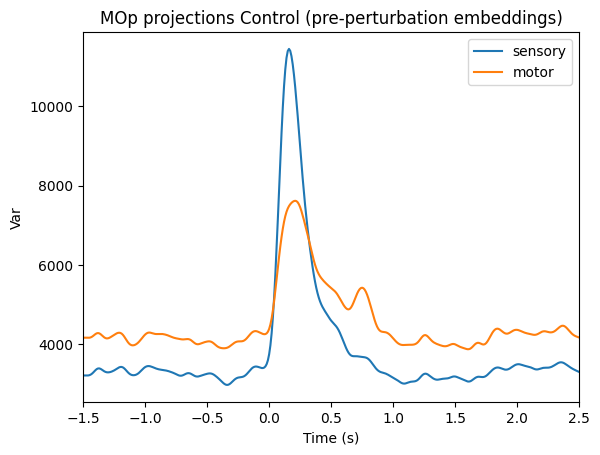

In [260]:
fig, ax = plt.subplots()
times = np.arange(-2, 3.01, step=0.01)
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'MOp_rates', embeddings["MOp"]["sensory_emb"]), label='sensory')
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'MOp_rates', embeddings["MOp"]["motor_emb"]), label='motor')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Var')

ax.set_title('MOp projections Control (pre-perturbation embeddings)')

ax.legend()
ax.set_xlim(-1.5, 2.5)
plt.show()

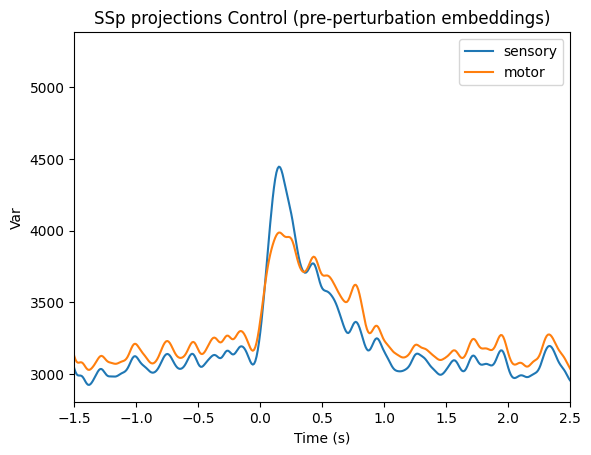

In [261]:
fig, ax = plt.subplots()
times = np.arange(-2, 3.01, step=0.01)
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'SSp_rates', embeddings["SSp"]["sensory_emb"]), label='sensory')
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'SSp_rates', embeddings["SSp"]["motor_emb"]), label='motor')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Var')

ax.set_title('SSp projections Control (pre-perturbation embeddings)')
ax.set_xlim(-1.5, 2.5)

ax.legend()
plt.show()

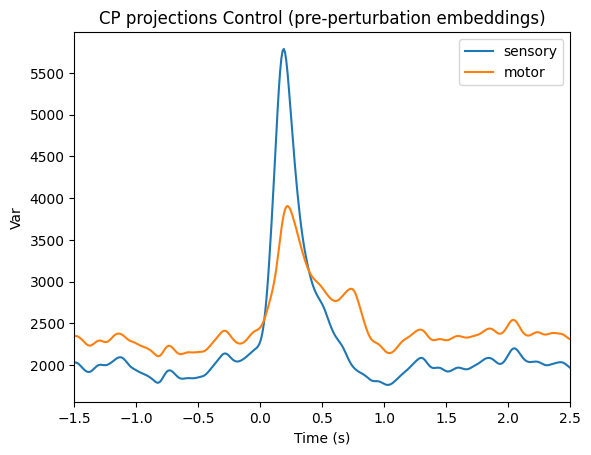

In [262]:
fig, ax = plt.subplots()
times = np.arange(-2, 3.01, step=0.01)
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'CP_rates', embeddings["CP"]["sensory_emb"]), label='sensory')
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'CP_rates', embeddings["CP"]["motor_emb"]), label='motor')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Var')

ax.set_title('CP projections Control (pre-perturbation embeddings)')
ax.set_xlim(-1.5, 2.5)

ax.legend()
plt.show()

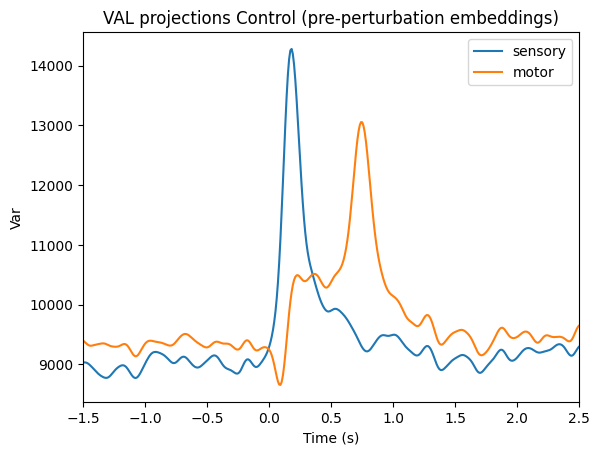

In [263]:
fig, ax = plt.subplots()
times = np.arange(-2, 3.01, step=0.01)
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'VAL_rates', embeddings["VAL"]["sensory_emb"]), label='sensory')
ax.plot(times, subspaces.variance_in_subspace_df(perturb_td, 'VAL_rates', embeddings["VAL"]["motor_emb"]), label='motor')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Var')

ax.set_title('VAL projections Control (pre-perturbation embeddings)')
ax.set_xlim(-1.5, 2.5)

ax.legend()
plt.show()

In [ ]:
subspaces.variance_in_subspace(
    np.concatenate(perturb_td.MOp_rates.values),
    embeddings["VAL"]["motor_emb"])

subspaces.variance_in_subspace(
    np.concatenate(perturb_td.MOp_rates.values),
    embeddings["VAL"]["sensory_emb"])

4816.499319251766

<BarContainer object of 20 artists>

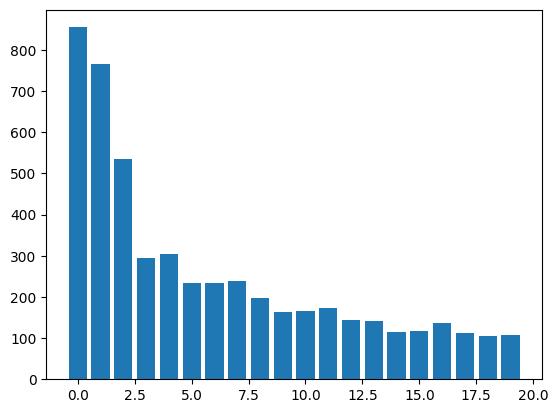

In [ ]:
fig, ax = plt.subplots()


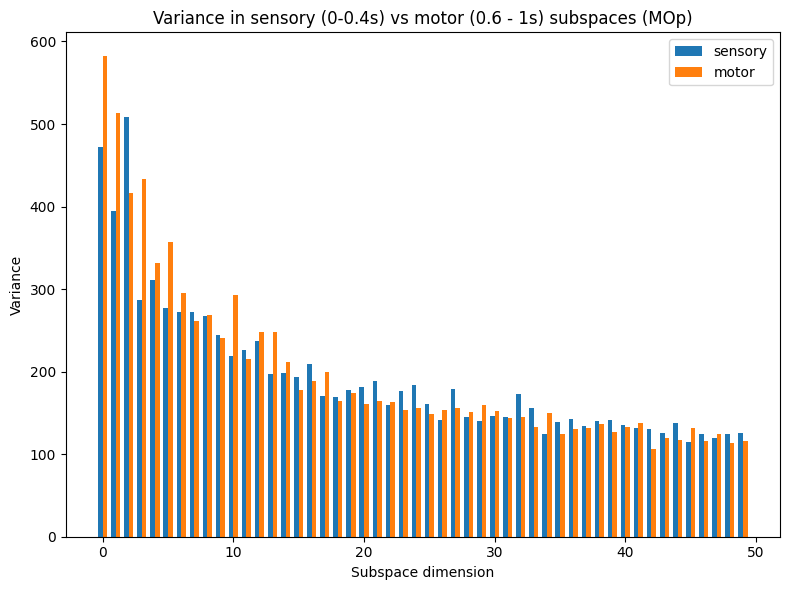

In [265]:
fig, ax = plt.subplots(figsize=(8,6))

# Compute variance in sensory and motor subspaces
vars_sens = subspaces.variance_in_dims(
    np.concatenate(perturb_td.VAL_rates.values),
    embeddings["VAL"]["sensory_emb"]
)

vars_mot = subspaces.variance_in_dims(
    np.concatenate(perturb_td.VAL_rates.values),
    embeddings["VAL"]["motor_emb"]
)

# x locations for groups
dims = np.arange(len(vars_sens))

# Bar width
width = 0.35

# Sensory bars (left)
ax.bar(dims - width/2, vars_sens, width, label='sensory')

# Motor bars (right)
ax.bar(dims + width/2, vars_mot, width, label='motor')

# Labels and legend
ax.set_xlabel("Subspace dimension")
ax.set_ylabel("Variance")
ax.set_title("Variance in sensory (0-0.4s) vs motor (0.6 - 1s) subspaces (MOp)")
ax.legend()

plt.tight_layout()
plt.show()


1. Geometry of sensory vs motor subspaces
1.1 Subspace alignment within each region

- Questions:

Are M1 sensory and motor subspaces nearly orthogonal, or strongly overlapping?
- Strongly overlapping kind of everywhere

1.2 Compare across regions

Do the same alignment analysis:

Between sensory subspaces of different regions (e.g. M1-sensory vs S1-sensory).

Between motor subspaces (e.g. M1-motor vs DLS-motor).

Cross-type (e.g. M1-sensory vs DLS-motor).

This can reveal whether:

Sensory representations are more similar across cortex (M1/S1) and more distinct subcortically.

Motor subspaces in M1 and DLS are more tightly aligned than their sensory subspaces, consistent with a shared “movement-correction manifold”.

2. Temporal dynamics of subspace engagement

Even though the PCs were defined in fixed windows, you can project the entire peri-perturbation time course onto each subspace.

2.1 Time-resolved variance in each subspace
Compute “energy” or variance:


Do sensory components peak immediately after the perturbation and then decline?
Do motor components ramp up later and stay elevated during correction?

Is there a clear temporal hand-off from sensory to motor subspace?

Compare this across regions:

Does M1 show earlier motor-subspace engagement than DLS/thalamus?

Does S1 show stronger sustained sensory-subspace energy?

2.2 Trajectory shapes

In each region:

For each trial type (solenoid, gait phase, etc.), plot condition-averaged trajectories:

In sensory space (first 2–3 sensory PCs).

In motor space (first 2–3 motor PCs).

Look for:

Rotational vs ramp-like dynamics within each subspace.

Whether trajectories for different perturbations diverge mainly in sensory space early, then in motor space later.

This allows you to describe whether, for example, M1 motor subspace shows rotations during corrective movements, while S1 sensory subspace has more transient, radial responses.

3. Behavioural and stimulus decoding restricted to each subspace

Even though you defined subspaces purely from PCA, you can now test their functional roles by constraining decoders.

3.1 Kinematic decoding

Train time-resolved linear decoders using:

Only sensory projections 
(zsens(t))
(z
sens
	​

(t)).

Only motor projections 
(zmot(t))
(z
mot
	​

(t)).

Full latent space (for an upper bound).

Decode:

Future kinematics (e.g. 30–100 ms ahead) to capture corrections.

Possibly also instantaneous kinematics.

Compare decoding performance (R², correlation) across the three cases:

Does the motor subspace carry most of the predictive power for future corrections?

Does the sensory subspace explain mainly instantaneous or slightly lagged kinematics (i.e. feedback)?

This gives an empirical functional label to your geometrically defined subspaces.

3.2 Solenoid identity decoding

Similarly, decode which solenoid fired from:

Sensory projections vs motor projections, as a function of time.

You should see:

Early high decoding from the sensory subspace (exogenous input).

Later decoding from both, with motor subspace capturing the “which solenoid → which movement” mapping.

You can also repeat decoding with very short windows vs longer windows to show explicitly that long windows pull in motor information.

4. Trial-by-trial variability and its link to behaviour

Because you have full-body 3D kinematics, you can ask how trial-to-trial differences in neural projections relate to trial-to-trial differences in corrective behaviour.

4.1 Early sensory projections predicting later corrections

For each trial:

Compute the average sensory projection in an early post-perturbation window (e.g. 0–30 ms): a vector of scores along the sensory PCs.

Compute behavioural summary measures:

Peak COM lateral displacement.

Latency of first corrective paw step.

Magnitude of body reorientation, etc.

Then:

Fit a linear (or regularised) regression from early sensory scores to these behavioural measures.

Or compute simple correlations component-wise.

Questions:

Do larger amplitudes in particular sensory PCs predict earlier or larger corrections?

Does this relationship differ across regions (e.g. stronger in M1 vs S1)?

This gives you something like a sensory → motor mapping mediated via these subspaces.

4.2 Motor projections explaining residual behavioural variance

Similarly, link motor subspace scores (e.g. 50–150 ms) to behaviour:

Does variance in motor projections capture trial-by-trial variability in corrective kinematics that is not explained by early sensory projections?

You can do hierarchical regression: behaviour ~ early sensory + motor scores.

If early sensory explains some portion and motor adds extra unique variance, that supports a genuine computational transformation between subspaces.

5. Inter-region coupling in sensory and motor coordinates

Because you have multiple regions, it is natural to study how they interact within these subspaces.

5.1 Time-lagged correlations / Granger-like analyses

For each pair of regions (A, B):

Compute time-resolved cross-correlations between:

zsensA(t)
z
sens
A
	​

(t) and 
zsensB(t+τ)
z
sens
B
	​

(t+τ),

zmotA(t)
z
mot
A
	​

(t) and 
zmotB(t+τ)
z
mot
B
	​

(t+τ),

Possibly cross-type (sensory A vs motor B).

From this you can extract:

Lead–lag structure in sensory vs motor subspaces:

E.g. does M1 sensory activity lead S1 sensory activity or vice versa?

Does M1 motor subspace lead DLS motor subspace during corrections?

If you are comfortable, you can formalise this with multivariate Granger causality or directed coherence on the subspace time series.

5.2 Canonical correlation between subspaces across regions

At particular time windows:

Perform CCA between the sensory subspace activity in M1 and S1, or motor subspace in M1 and DLS.

Questions:

Are sensory representations more strongly shared cortico-cortically, and motor ones more cortico-subcortical?

Does CCA strength change from early to late windows, consistent with a shift of locus of control?

6. Adaptation and “control mode” changes

You already have pre- vs post-perturbation periods and evidence that the “dominant covariation patterns” rotate.

With your sensory/motor PCA definition you can:

6.1 Recompute subspaces in different epochs

Compute sensory and motor subspaces separately in:

Early, naïve perturbations.

Late, adapted perturbations.

(Optionally) pre-perturbation running as a baseline.

Then:

Quantify the angle between early and late sensory subspaces.

Same for motor subspaces.

Ask whether most of the rotation you observed earlier is:

Concentrated in the motor subspace (change in control strategy).

Or also in the sensory subspace (change in how perturbations are encoded).

6.2 Changes in functional role

Repeat the decoding and behaviour-linking analyses above separately for each epoch:

Does motor-subspace-based kinematic decoding improve with learning?

Does the dependency of behaviour on sensory vs motor projections change (e.g. behaviour becomes less sensitive to sensory variability because motor control is more robust)?

This gives a very clean story about how subspaces reconfigure with adaptation.

If you tell me which of these you are most likely to run first (e.g. decoding vs geometry vs interaction analyses), I can sketch a very explicit analysis pipeline (including exact matrices and steps) for that specific part.

Principal angles (radians):
[1.51095923 1.49487781 1.4154831  1.34511571 1.33803553 1.26562454
 1.19531828 1.10715569 0.99177203 0.88762654]

Principal angles (degrees):
[86.57158676 85.65018933 81.10120779 77.06945288 76.66378863 72.51494451
 68.4866928  63.43534823 56.8243513  50.85725436]


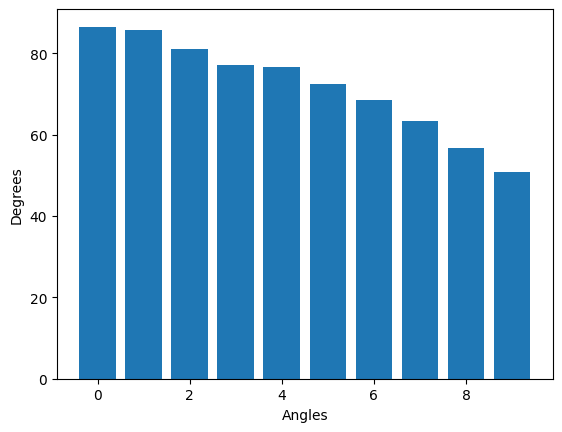

In [175]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.linalg import subspace_angles

# ---------------------------------------------------------
# Example neural data
# X1: data for condition/region 1  (neurons × timepoints)
# X2: data for condition/region 2  (neurons × timepoints)
# ---------------------------------------------------------

np.random.seed(0)
n_neurons = 80
t1 = 500
t2 = 500

# Simulated example data
X1 = np.random.randn(n_neurons, t1)
X2 = np.random.randn(n_neurons, t2)

# ---------------------------------------------------------
# Step 1: Fit PCA for each dataset
# ---------------------------------------------------------

# Choose dimensionality of PCA subspace
k = 10  # typically 5–20 depending on data variance

pca1 = PCA(n_components=k)
pca2 = PCA(n_components=k)

# Fit on the transpose because sklearn expects samples × features
U1 = pca1.fit_transform(X1.T)     # shape time × k
U2 = pca2.fit_transform(X2.T)

# But we need the PCA *loading vectors* (orthonormal basis)
# These are in components_.T with shape neurons × k
B1 = pca1.components_.T           # basis for subspace 1
B2 = pca2.components_.T           # basis for subspace 2

# ---------------------------------------------------------
# Step 2: Compute principal angles
# ---------------------------------------------------------

angles = subspace_angles(B1, B2)     # returns angles in radians

# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------
print("Principal angles (radians):")
print(angles)

print("\nPrincipal angles (degrees):")
print(np.degrees(angles))

# Smallest angle = strongest shared direction
# Largest angle   = most orthogonal dimension


fig, ax = plt.subplots()
ax.bar(range(len(angles)), np.degrees(angles))
ax.set_ylabel('Degrees')
ax.set_xlabel('Angles')
plt.show()

## Future and past decoding

In [52]:
# Define intertrial dataframe
df_all = dt.add_pca_df(df_)
df_all = dt.add_bhv(df_all)

df_inter = pyal.select_trials(df_all, df_all.trial_name == 'intertrial')
# df_inter = pyal.select_trials(df_all, df_all.trial_name == 'trial')
# df_inter = dt.remove_trials_wo_motion_before_event(df_inter, 'idx_motion', 'idx_sol_on')
# df_inter = df_inter[~df_inter["values_Sol_duration"].isin([50, 100])]


df_inter['tr_start'] = 0
df_inter = pyal.select_trials(df_inter, df_inter.trial_length > 100)
df_inter['idx_motion'] = df_inter['idx_motion'].apply(
    lambda x: x if isinstance(x, np.ndarray) else np.array([x])
)
df_inter = pyal.select_trials(df_inter, lambda trial: len(trial.idx_motion) > (trial.trial_length / 40))


In [53]:
df_trials = pyal.select_trials(df_all, df_all.trial_name == 'trial')
df_trials = dt.remove_trials_wo_motion_before_event(df_trials, 'idx_motion', 'idx_sol_on')
df_trials = pyal.restrict_to_interval(df_trials, 'idx_sol_on', rel_start = -200, rel_end= 200)
df_trials = df_trials[~df_trials["values_Sol_duration"].isin([50, 100])]


Dropped 11 of 333 rows (3.30%).


In [61]:
# Roll it and cut it
keypoint = 'left_paw'
df_inter_no_roll = df_inter.copy()
df_inter_no_roll = pyal.restrict_to_interval(
    df_inter_no_roll, 
    'tr_start', 
    rel_start = 20, 
    rel_end = 280
)

df_inter_roll_past = df_inter.copy()
df_inter_roll_past[keypoint] = df_inter_roll_past[keypoint].apply(
    lambda trial: dim._roll_array(trial, shift=3, axis=0)
)
# df_inter_roll_past = pyal.restrict_to_interval(df_inter_roll_past, 'idx_sol_on', rel_start = -10, rel_end= 100)

df_inter_roll_past = pyal.restrict_to_interval(
    df_inter_roll_past, 
    'tr_start', 
    rel_start = 20, 
    rel_end = 280
)

df_inter_roll_future = df_inter.copy()
df_inter_roll_future[keypoint] = df_inter_roll_future[keypoint].apply(
    lambda trial: dim._roll_array(trial, shift=-5, axis=0)
)
# df_inter_roll_future = pyal.restrict_to_interval(df_inter_roll_future, 'idx_sol_on', rel_start = -10, rel_end= 100)

df_inter_roll_future = pyal.restrict_to_interval(
    df_inter_roll_future, 
    'tr_start', 
    rel_start = 20, 
    rel_end = 280
)

In [94]:
def compute_embedding(td, signal_x, signal_y, time_bin_window, model, k=150):

    X = np.stack(td[signal_x].values)
    y = np.stack(td[signal_y].values)
    n_trials, n_time, n_feat_in = X.shape
    n_trials, n_time, n_feat_out = y.shape

    # Slice time window and reshape
    X, y = X[:, time_bin_window[0]:time_bin_window[1], :], y[:, time_bin_window[0]:time_bin_window[1], :]
    X, y = X.reshape(-1, n_feat_in), y.reshape(-1, n_feat_out)
    
    if model == 'pca':
        pca_model = dim.compute_pca(X, n_components=k)
        W = pca_model.components_.T
    else:

        model.fit(X, y)
        W = scipy.linalg.orth(model.coef_.T)

    return W

In [81]:
# time goes from -200 to 200
W_pre= compute_embedding(df_trials, 'MOp_rates_pca', 'bhv', (50, 100), Ridge())
W_sensory = compute_embedding(df_trials, 'MOp_rates_pca', 'bhv', (210, 220), Ridge())
W_motor = compute_embedding(df_trials, 'MOp_rates_pca', 'bhv', (220, 270), Ridge())


In [83]:
df_inter_roll_past = subspaces.project_signal(
    df_inter_roll_past,
    W_sensory,
    'MOp_rates_pca',
    'MOp_rates_pca_sensory'
)

df_inter_roll_past = subspaces.project_signal(
    df_inter_roll_past,
    W_motor,
    'MOp_rates_pca',
    'MOp_rates_pca_motor'
)
df_inter_roll_past = subspaces.project_signal(
    df_inter_roll_past,
    W_pre,
    'MOp_rates_pca',
    'MOp_rates_pca_pre'
)


df_inter_roll_future = subspaces.project_signal(
    df_inter_roll_future,
    W_sensory,
    'MOp_rates_pca',
    'MOp_rates_pca_sensory'
)

df_inter_roll_future = subspaces.project_signal(
    df_inter_roll_future,
    W_motor,
    'MOp_rates_pca',
    'MOp_rates_pca_motor'
)
df_inter_roll_future = subspaces.project_signal(
    df_inter_roll_future,
    W_pre,
    'MOp_rates_pca',
    'MOp_rates_pca_pre'
)


df_inter_no_roll = subspaces.project_signal(
    df_inter_no_roll,
    W_sensory,
    'MOp_rates_pca',
    'MOp_rates_pca_sensory'
)

df_inter_no_roll = subspaces.project_signal(
    df_inter_no_roll,
    W_motor,
    'MOp_rates_pca',
    'MOp_rates_pca_motor'
)
df_inter_no_roll = subspaces.project_signal(
    df_inter_no_roll,
    W_pre,
    'MOp_rates_pca',
    'MOp_rates_pca_pre'
)


In [ ]:
# df_inter_roll_future = df_inter_roll_future.sample(frac=1, random_state=42).reset_index(drop=True)
# df_inter_roll_past = df_inter_roll_past.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
sens_scores_past = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_past.MOp_rates_pca_sensory.values),
    np.concatenate(df_inter_roll_past[keypoint].values),
    cv=KFold(5, shuffle=False),
    scoring=decode.get_custom_scorer()
)
sens_scores_future = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_future.MOp_rates_pca_sensory.values),
    np.concatenate(df_inter_roll_future[keypoint].values),
    cv=KFold(5, shuffle=False),
    scoring=decode.get_custom_scorer()
)

print(f"Sensory embedding. Past score: {sens_scores_past.mean():.4f}+-{sens_scores_past.std():.4f}, "
      f"Future score: {sens_scores_future.mean():.4f}+-{sens_scores_future.std():.4f}"
)


Sensory embedding. Past score: 0.0832+-0.0330, Future score: 0.1028+-0.0115


In [ ]:
motor_scores_past = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_past.MOp_rates_pca_motor.values),
    np.concatenate(df_inter_roll_past[keypoint].values),
    cv=KFold(5, shuffle=False),
    scoring=decode.get_custom_scorer()
)
motor_scores_future = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_future.MOp_rates_pca_motor.values),
    np.concatenate(df_inter_roll_future[keypoint].values),
    cv=KFold(5, shuffle=False),
    scoring=decode.get_custom_scorer()
)

print(f"Motor embedding. Past score: {motor_scores_past.mean():.4f}+-{motor_scores_past.std():.4f}, "
      f"Future score: {motor_scores_future.mean():.4f}+-{motor_scores_future.std():.4f}"
)

Motor embedding. Past score: 0.0808+-0.0134, Future score: 0.0714+-0.0217


In [20]:
pre_scores_past = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_past.MOp_rates_pca_pre.values),
    np.concatenate(df_inter_roll_past[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)
pre_scores_future = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_future.MOp_rates_pca_pre.values),
    np.concatenate(df_inter_roll_future[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(f"Pre embedding. Past score: {pre_scores_past.mean():.4f}+-{pre_scores_past.std():.4f}, "
      f"Future score: {pre_scores_future.mean():.4f}+-{pre_scores_future.std():.4f}"
)

Pre embedding. Past score: 0.2041+-0.0479, Future score: 0.1900+-0.0424


### Try with no rolling

In [84]:
pre_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_no_roll.MOp_rates_pca_pre.values),
    np.concatenate(df_inter_no_roll[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

motor_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_no_roll.MOp_rates_pca_motor.values),
    np.concatenate(df_inter_no_roll[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(f"No roll. Pre embedding score: {pre_scores.mean():.4f}+-{pre_scores.std():.4f}")
print(f"No roll. Perturb embedding score: {motor_scores.mean():.4f}+-{motor_scores.std():.4f}")



No roll. Pre embedding score: 0.1830+-0.0548
No roll. Perturb embedding score: 0.1551+-0.0567


In [85]:
pre_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_future.MOp_rates_pca_pre.values),
    np.concatenate(df_inter_roll_future[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

motor_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_future.MOp_rates_pca_motor.values),
    np.concatenate(df_inter_roll_future[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(f"Future. Pre embedding score: {pre_scores.mean():.4f}+-{pre_scores.std():.4f}")
print(f"Future. Perturb embedding score: {motor_scores.mean():.4f}+-{motor_scores.std():.4f}")



Future. Pre embedding score: 0.1639+-0.0403
Future. Perturb embedding score: 0.1410+-0.0402


In [86]:
pre_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_past.MOp_rates_pca_pre.values),
    np.concatenate(df_inter_roll_past[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

sens_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_past.MOp_rates_pca_sensory.values),
    np.concatenate(df_inter_roll_past[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(f"Future. Pre embedding score: {pre_scores.mean():.4f}+-{pre_scores.std():.4f}")
print(f"Future. Perturb embedding score: {sens_scores.mean():.4f}+-{sens_scores.std():.4f}")



Future. Pre embedding score: 0.1800+-0.0395
Future. Perturb embedding score: 0.1215+-0.0339


### try with pca embeddings

In [95]:
# time goes from -200 to 200
W_pre= compute_embedding(df_trials, 'MOp_rates', 'bhv', (50, 100), 'pca')
W_sensory = compute_embedding(df_trials, 'MOp_rates', 'bhv', (210, 220), 'pca')
W_motor = compute_embedding(df_trials, 'MOp_rates', 'bhv', (220, 270), 'pca')


In [96]:
df_inter_roll_past = subspaces.project_signal(
    df_inter_roll_past,
    W_sensory,
    'MOp_rates',
    'MOp_rates_pca_sensory'
)

df_inter_roll_past = subspaces.project_signal(
    df_inter_roll_past,
    W_motor,
    'MOp_rates',
    'MOp_rates_pca_motor'
)
df_inter_roll_past = subspaces.project_signal(
    df_inter_roll_past,
    W_pre,
    'MOp_rates',
    'MOp_rates_pca_pre'
)


df_inter_roll_future = subspaces.project_signal(
    df_inter_roll_future,
    W_sensory,
    'MOp_rates',
    'MOp_rates_pca_sensory'
)

df_inter_roll_future = subspaces.project_signal(
    df_inter_roll_future,
    W_motor,
    'MOp_rates',
    'MOp_rates_pca_motor'
)
df_inter_roll_future = subspaces.project_signal(
    df_inter_roll_future,
    W_pre,
    'MOp_rates',
    'MOp_rates_pca_pre'
)


df_inter_no_roll = subspaces.project_signal(
    df_inter_no_roll,
    W_sensory,
    'MOp_rates',
    'MOp_rates_pca_sensory'
)

df_inter_no_roll = subspaces.project_signal(
    df_inter_no_roll,
    W_motor,
    'MOp_rates',
    'MOp_rates_pca_motor'
)
df_inter_no_roll = subspaces.project_signal(
    df_inter_no_roll,
    W_pre,
    'MOp_rates',
    'MOp_rates_pca_pre'
)


In [97]:
pre_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_no_roll.MOp_rates_pca_pre.values),
    np.concatenate(df_inter_no_roll[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

motor_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_no_roll.MOp_rates_pca_motor.values),
    np.concatenate(df_inter_no_roll[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(f"No roll. Pre embedding score: {pre_scores.mean():.4f}+-{pre_scores.std():.4f}")
print(f"No roll. Perturb embedding score: {motor_scores.mean():.4f}+-{motor_scores.std():.4f}")



No roll. Pre embedding score: 0.2078+-0.0554
No roll. Perturb embedding score: 0.2064+-0.0563


In [98]:
pre_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_future.MOp_rates_pca_pre.values),
    np.concatenate(df_inter_roll_future[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

motor_scores = cross_val_score(
    Ridge(),
    np.concatenate(df_inter_roll_future.MOp_rates_pca_motor.values),
    np.concatenate(df_inter_roll_future[keypoint].values),
    cv=5,
    scoring=decode.get_custom_scorer()
)

print(f"Future. Pre embedding score: {pre_scores.mean():.4f}+-{pre_scores.std():.4f}")
print(f"Future. Perturb embedding score: {motor_scores.mean():.4f}+-{motor_scores.std():.4f}")



Future. Pre embedding score: 0.1712+-0.0562
Future. Perturb embedding score: 0.1673+-0.0571


In [100]:
handler = decode.DecodingDataHandler(
    data_dir='/data/bnd-data/raw/', 
    session='M078_2025_08_05_15_30',
    combine_time_bins=False
)
df_ = handler.df.copy()


fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'values_Sol_duration'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
fields: ['values_before_camera_trigger', 'values_Sol_direction', 'idx_Sol_direction', 'values_Sol_duration', 'idx_Sol_duration', 'idx_sol_on'] could not be converted to int.
['VAL_spikes', 'SSp_spikes', 'all_spikes', 'MOp_spikes', 'CP_spikes', 'MOs_spikes']


/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.81132075471699% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of VAL_spikes on 99.81132075471699% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.81132075471699% of trials
  warnings.warn(
/home/me24/repos/pyaldata/pyaldata/utils.py:155: UserWarning: idx_MotSen1_Y might be a time-varying field. It matches the length of VAL_spikes on 99.81132075471699% of trials
  warnings.warn(


Resulting VAL_spikes ephys data shape is (NxT): (143, 120000)
Resulting SSp_spikes ephys data shape is (NxT): (114, 120000)
Resulting all_spikes ephys data shape is (NxT): (291, 120000)
Resulting MOp_spikes ephys data shape is (NxT): (55, 120000)
Resulting CP_spikes ephys data shape is (NxT): (254, 120000)
Resulting MOs_spikes ephys data shape is (NxT): (112, 120000)


# Do perturb subspace and comm subspace overlap?

In [188]:
df_all = dt.add_pca_df(df_)
df_all = dt.add_bhv(df_all)

In [264]:
df_trials = pyal.select_trials(df_, df_.trial_name == 'trial')
df_trials = dt.add_pca_df(df_trials)

In [265]:
# df_trials = dt.add_bhv(df_trials, bhv_fields=bhv_combinations['left_paw'])
df_trials = dt.add_bhv(df_trials)

df_trials = dt.remove_trials_wo_motion_before_event(df_trials, 'idx_motion', 'idx_sol_on')
df_trials = pyal.restrict_to_interval(df_trials, 'idx_sol_on', rel_start = -200, rel_end= 200)

Dropped 11 of 333 rows (3.30%).


In [216]:
perturb_subspace = subspaces.compute_embedding(
    df_trials, 'MOp_rates_pca', 'bhv', (260, 280), subspaces.ReducedRankCommSubspace(rank=20)
)

pre_perturb_subspace = subspaces.compute_embedding(
    df_trials, 'MOp_rates_pca', 'bhv', (50, 70), subspaces.ReducedRankCommSubspace(rank=20)
)
comm_subspace = {}
areas = ['SSp', 'CP', 'VAL']
for area in areas:
    comm_cp_subspace = subspaces.compute_embedding(
        df_trials, 'MOp_rates_pca', f'{area}_rates', (50, 70), subspaces.ReducedRankCommSubspace(rank=20)
    )
    perturb_overlap = subspaces.compute_overlap_between_subspaces(perturb_subspace, comm_cp_subspace)
    pre_overlap = subspaces.compute_overlap_between_subspaces(pre_perturb_subspace, comm_cp_subspace)

    print(f"Area: {area} Pre overlap: {pre_overlap:.4f}, Perturb overlap: {perturb_overlap:.4f}")





Area: SSp Pre overlap: 0.2618, Perturb overlap: 0.1755
Area: CP Pre overlap: 0.2548, Perturb overlap: 0.2021
Area: VAL Pre overlap: 0.2550, Perturb overlap: 0.1981


In [206]:
perturb_overlap = subspaces.compute_overlap_between_subspaces(perturb_subspace, comm_cp_subspace)
pre_overlap = subspaces.compute_overlap_between_subspaces(pre_perturb_subspace, comm_cp_subspace)

print(f"Pre overlap: {pre_overlap:.4f}, Perturb overlap: {perturb_overlap:.4f}")

Pre overlap: 0.2113, Perturb overlap: 0.1942


In [180]:
perturb_subspace = subspaces.compute_embedding(
    df_trials, 'VAL_rates', 'bhv', (200, 300), 'pca', k=50
)

pre_perturb_subspace = subspaces.compute_embedding(
    df_trials, 'VAL_rates', 'bhv', (50, 150), 'pca', k=50
)


# comm_cp_subspace = subspaces.compute_embedding(
#     df_trials, 'MOp_rates_pca', 'CP_rates_pca', (0, 399), decode.ReducedRankRegressorBence(rank=10)
# )

comm_cp_subspace = subspaces.compute_embedding(
    df_trials, 'VAL_rates', 'CP_rates', (0, 399), subspaces.ReducedRankCommSubspace(rank=50)
)

perturb_overlap = subspaces.compute_overlap_between_subspaces(perturb_subspace, comm_cp_subspace)
pre_overlap = subspaces.compute_overlap_between_subspaces(pre_perturb_subspace, comm_cp_subspace)

print(f"Pre overlap: {pre_overlap:.4f}, Perturb overlap: {perturb_overlap:.4f}")

Pre overlap: 0.2334, Perturb overlap: 0.2471


In [146]:
comm_ssp_subspace = subspaces.compute_embedding(
    df_trials, 'VAL_rates_pca', 'MOp_rates_pca', (50, 60), subspaces.ReducedRankCommSubspace(rank=20)
)


comm_cp_subspace = subspaces.compute_embedding(
    df_trials, 'VAL_rates_pca', 'CP_rates_pca', (50, 60), subspaces.ReducedRankCommSubspace(rank=20)
)

mop_ssp__mop_cp_overlap = subspaces.compute_overlap_between_subspaces(comm_ssp_subspace, comm_cp_subspace)

print(f"CP/SSp from MOp overlap: {mop_ssp__mop_cp_overlap:.4f}")

CP/SSp from MOp overlap: 0.4409


In [147]:
comm_ssp_subspace = subspaces.compute_embedding(
    df_trials, 'VAL_rates_pca', 'MOp_rates_pca', (230, 240), subspaces.ReducedRankCommSubspace(rank=20)
)


comm_cp_subspace = subspaces.compute_embedding(
    df_trials, 'VAL_rates_pca', 'CP_rates_pca', (230, 240), subspaces.ReducedRankCommSubspace(rank=20)
)

mop_ssp__mop_cp_overlap = subspaces.compute_overlap_between_subspaces(comm_ssp_subspace, comm_cp_subspace)

print(f"CP/SSp from MOp overlap: {mop_ssp__mop_cp_overlap:.4f}")

CP/SSp from MOp overlap: 0.4545


## A bit more systematically

In [ ]:
df_trials = pyal.select_trials(df_, df_.trial_name == 'trial')
df_trials = dt.add_pca_df(df_trials)
df_trials = dt.add_bhv(df_trials, bhv_combinations['forelimbs'])

df_trials = dt.remove_trials_wo_motion_before_event(df_trials, 'idx_motion', 'idx_sol_on')
df_trials = pyal.restrict_to_interval(df_trials, 'idx_sol_on', rel_start = -200, rel_end= 200)
# df_trials = df_trials[~df_trials["values_Sol_duration"].isin([50, 100])]


Dropped 11 of 333 rows (3.30%).


In [267]:
# Overlaps between potent and comm subspaces


perturb_overlaps = {}
areas = ['MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    perturb_overlaps[area] = {}
    potent_subspace = subspaces.compute_embedding(
        df_trials, f'{area}_rates_pca', 'bhv', (200, 250), decode.ReducedRankRegressorBence(rank=10)
    )
    for area_ in areas:
        if area_ == area:
            continue
        comm_subspace = subspaces.compute_embedding(
            df_trials, f'{area}_rates_pca', f'{area_}_rates_pca', (200, 250), decode.ReducedRankRegressorBence(rank=10)
        )
        overlap = subspaces.compute_overlap_between_subspaces(potent_subspace, comm_subspace)
        perturb_overlaps[area][area_] = overlap

        print(f"Overlap {area} -> {area_}: {overlap:.4f}")





(178, 62)
(178, 69)
Overlap MOp -> SSp: 0.1694
(178, 172)
Overlap MOp -> CP: 0.1935
(178, 168)
Overlap MOp -> VAL: 0.1823
(69, 62)
(69, 178)
Overlap SSp -> MOp: 0.3602
(69, 172)
Overlap SSp -> CP: 0.3105
(69, 168)
Overlap SSp -> VAL: 0.3474
(172, 62)
(172, 178)
Overlap CP -> MOp: 0.1858
(172, 69)
Overlap CP -> SSp: 0.1868
(172, 168)
Overlap CP -> VAL: 0.1769
(168, 62)
(168, 178)
Overlap VAL -> MOp: 0.2684
(168, 69)
Overlap VAL -> SSp: 0.1996
(168, 172)
Overlap VAL -> CP: 0.2181


In [268]:
pre_overlaps = {}
areas = ['MOp', 'SSp', 'CP', 'VAL']
for area in areas:
    pre_overlaps[area] = {}
    potent_subspace = subspaces.compute_embedding(
        df_trials, f'{area}_rates_pca', 'bhv', (40, 90), decode.ReducedRankRegressorBence(rank=10)
    )
    for area_ in areas:
        if area_ == area:
            continue
        comm_subspace = subspaces.compute_embedding(
            df_trials, f'{area}_rates_pca', f'{area_}_rates_pca', (40, 90), decode.ReducedRankRegressorBence(rank=10)
        )
        overlap = subspaces.compute_overlap_between_subspaces(potent_subspace, comm_subspace)
        pre_overlaps[area][area_] = overlap

        print(f"Overlap {area} -> {area_}: {overlap:.4f}")




(178, 62)
(178, 69)
Overlap MOp -> SSp: 0.1514
(178, 172)
Overlap MOp -> CP: 0.1523
(178, 168)
Overlap MOp -> VAL: 0.1468
(69, 62)
(69, 178)
Overlap SSp -> MOp: 0.3931
(69, 172)
Overlap SSp -> CP: 0.3200
(69, 168)
Overlap SSp -> VAL: 0.3209
(172, 62)
(172, 178)
Overlap CP -> MOp: 0.2122
(172, 69)
Overlap CP -> SSp: 0.1479
(172, 168)
Overlap CP -> VAL: 0.1623
(168, 62)
(168, 178)
Overlap VAL -> MOp: 0.2893
(168, 69)
Overlap VAL -> SSp: 0.1941
(168, 172)
Overlap VAL -> CP: 0.2314


In [262]:
perturb_td = pyal.restrict_to_interval(df, 'idx_sol_on', rel_start = -200, rel_end=300)

Z_all = np.hstack(
    [np.concatenate(perturb_td.MOp_rates.values),
    np.concatenate(perturb_td.SSp_rates.values),
    np.concatenate(perturb_td.CP_rates.values),
    np.concatenate(perturb_td.VAL_rates.values),]

)
k = 200
global_pca = dim.compute_pca(Z_all, n_components=k)
W_global = global_pca.components_.T 

region_latents = {}
region_embeddings = {}

n_neurons = 0

k_pre = 50
k_mot  = 50

for area in areas:
    region_embeddings[area] = {}

    area_activity = np.concatenate(perturb_td[f"{area}_rates"].values)
    n_trials, n_time, area_neurons = np.stack(perturb_td[f"{area}_rates"].values).shape


    region_latents[area] = area_activity @ W_global[n_neurons:n_neurons + area_neurons]

    region_latents[area] = region_latents[area].reshape(n_trials, n_time, k)
    regions_latents_pre = region_latents[area][:, 200:250, :]
    regions_latents_perturb = region_latents[area][:, 50:100, :]

    pre_pca = dim.compute_pca(regions_latents_pre.reshape(-1, k), n_components=k_pre)
    region_embeddings[area]["pre_emb"] = pre_pca.components_.T

    motor_pca = dim.compute_pca(regions_latents_perturb.reshape(-1, k), n_components=k_mot)
    region_embeddings[area]["motor_emb"] = motor_pca.components_.T


    n_neurons = n_neurons + area_neurons

res = {}
for emb in region_embeddings[area].keys():
    res[emb] = {}
    for area in areas:
        res[emb][area] = {}

        for area_ in areas:
            angles = scipy.linalg.subspace_angles(region_embeddings[area][emb], region_embeddings[area_][emb])
            overlap =  np.mean(np.cos(angles)**2)
            res[emb][area][area_] = overlap

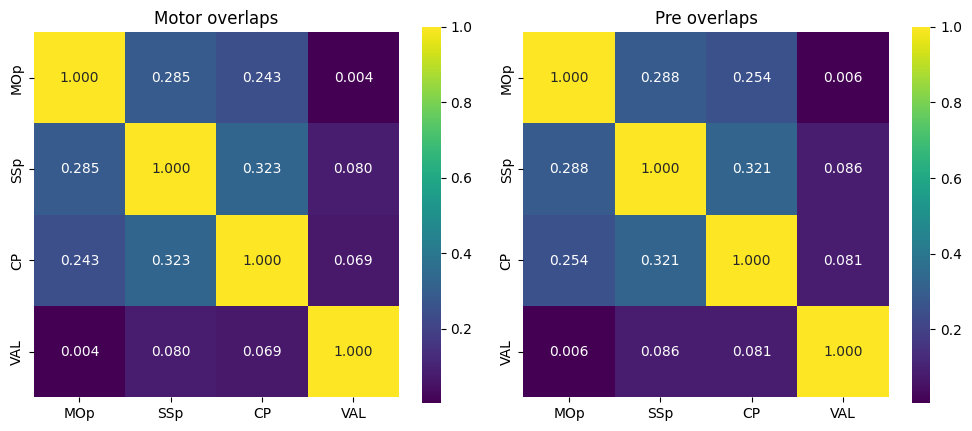

In [263]:
matrix_mot = np.zeros((len(areas), len(areas)))
matrix_sen = np.zeros((len(areas), len(areas)))

for i, a1 in enumerate(areas):
    for j, a2 in enumerate(areas):
        matrix_mot[i, j] = res['motor_emb'][a1][a2]
        matrix_sen[i, j] = res['pre_emb'][a1][a2]


fig, ax = plt.subplots(1, 2, figsize=(10,5))
sns.heatmap(
    matrix_mot, 
    annot=True,       # write numbers in the boxes
    cmap="viridis",   
    xticklabels=areas,
    yticklabels=areas,
    square=True,
    ax=ax[0],
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)

sns.heatmap(
    matrix_sen, 
    annot=True,       # write numbers in the boxes
    cmap="viridis",   
    xticklabels=areas,
    yticklabels=areas,
    square=True,
    ax=ax[1],
    fmt=".3f",
    cbar_kws={"shrink": 0.8},
)

ax[0].set_title("Motor overlaps")
ax[1].set_title("Pre overlaps")

plt.tight_layout()
plt.show()